# Análise Exploratória dos dados

In [433]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy ngboost

In [434]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold
from catboost import CatBoostRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from ngboost import NGBRegressor
from xgboost import XGBRegressor
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.base import clone
from tqdm.notebook import tqdm
import os, shap
import seaborn as sns
import pandas as pd
import numpy as np

In [435]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [436]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
print(file.sheet_names)

['BD_ML_Resis', 'BD_ML_Slump_1', 'Dicionario_Variaveis']


In [437]:
df_resistencia = file.parse('BD_ML_Resis')
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  599 non-null    object 
 1   ID_Mistura                   599 non-null    object 
 2   Tipo_Cimento_Classe          599 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      462 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  414 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        262 non-null    float64
 7   Massa_Esp_Brita_g_cm3        273 non-null    float64
 8   Cimento_kg_m3                599 non-null    float64
 9   Filer_Calcario_kg_m3         599 non-null    float64
 10  Agua_kg_m3                   599 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   599 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  599 non-null    float64
 13  Superplastificante_k

In [438]:
df_resistencia.Tipo_Cimento_Classe.sort_values(ascending=False).value_counts()

,count
Tipo_Cimento_Classe,
"CEM I 42,5 N",175
ASTM C 150 Type I,75
CP-V ARI,51
Type I OPC,50
"CEM I 42,5 R",41
OPC,40
Type I Portland,24
"P,I 42,5 (CEM I)",21
OPC (ASTM C150),21


In [439]:
autores = df_resistencia['Autores/ano'].unique()

for autor in autores:
    df_autor = df_resistencia[df_resistencia['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_resistencia)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 15 | 2.50%
Guemmadi et al, 2009, Número de amostras: 26 | 4.34%
Meddah et al 2014, Número de amostras: 175 | 29.22%
A Morzouki 2016, Número de amostras: 35 | 5.84%
Bentz et al, 2015, Número de amostras: 11 | 1.84%
Feltrin 2018, Número de amostras: 36 | 6.01%
Gyu Don Moon 2017, Número de amostras: 24 | 4.01%
Hieu T Cam 2010, Número de amostras: 12 | 2.00%
Md Jahidul Islam 2025, Número de amostras: 15 | 2.50%
Diab et al, (2016), Número de amostras: 24 | 4.01%
Mohammed e Al-Numan (2024), Número de amostras: 15 | 2.50%
Leeuwen et al, (2016), Número de amostras: 50 | 8.35%
Ramezanianpour et al. (2009), Número de amostras: 75 | 12.52%
Bayan 2018, Número de amostras: 25 | 4.17%
Bonavetti et al. (2000)., Número de amostras: 9 | 1.50%
Tsivilis et al. (2003), Número de amostras: 10 | 1.67%
Sun e Chen 2018, Número de amostras: 21 | 3.51%
Abdul-Ghani et al, 2019, Número de amostras: 21 | 3.51%


In [440]:
dos_santos_mask = df_resistencia['Autores/ano'] == 'Dos Santos et al, 2024'
df_resistencia = df_resistencia[~dos_santos_mask]

In [441]:
classe_encoder = LabelEncoder()
df_resistencia['cod_classe'] = classe_encoder.fit_transform(df_resistencia['Tipo_Cimento_Classe'])
df_resistencia['cod_classe'].value_counts()

,count
cod_classe,
6,175
0,75
17,50
7,41
13,40
10,36
18,24
15,21
14,21


/tmp/ipykernel_58898/1906372192.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


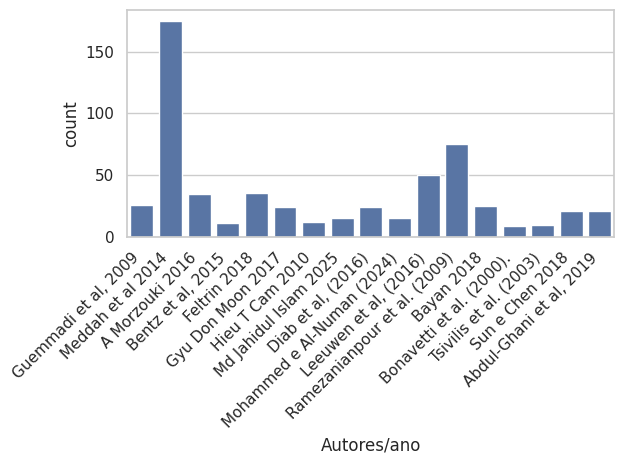

In [442]:
ax = sns.countplot(x='Autores/ano', data=df_resistencia)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

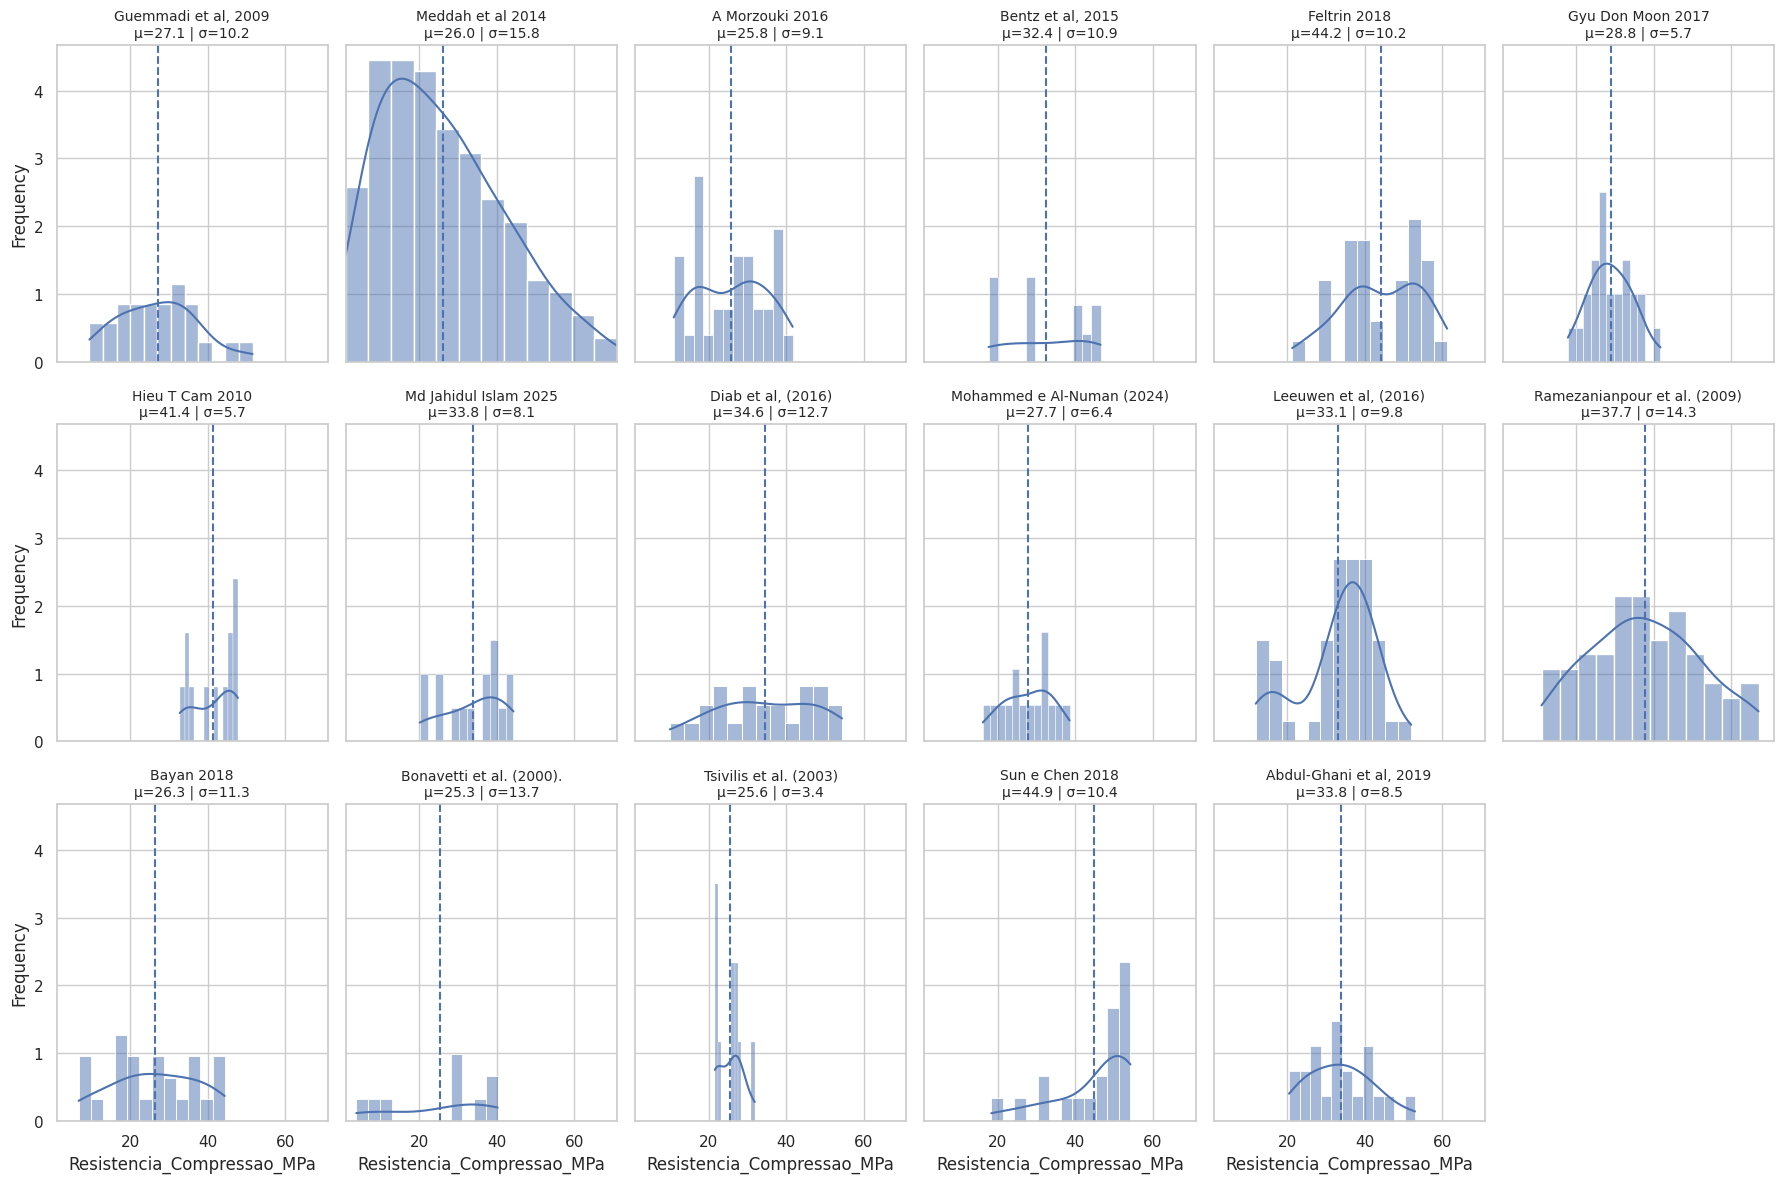

In [443]:
sns.set_style("whitegrid")
autores = df_resistencia['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_resistencia['Resistencia_Compressao_MPa'].min()
xmax = df_resistencia['Resistencia_Compressao_MPa'].max()

for i, autor in enumerate(autores):

    df_autor = df_resistencia[
        df_resistencia['Autores/ano'] == autor
    ]
    media = df_autor['Resistencia_Compressao_MPa'].mean()
    std = df_autor['Resistencia_Compressao_MPa'].std()
    sns.histplot(
        data=df_autor,
        x='Resistencia_Compressao_MPa',
        bins=12,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [444]:
columns = df_resistencia.columns

target_list = {'Resistencia_Compressao_MPa', 'Relacao_Agua_Cimento', 'Relacao_Agua_Aglomerante', 
               'Superplastificante_kg_m3', 'Filer_Calcario_kg_m3', 'Agua_kg_m3', 'Cimento_kg_m3',
               'Agregado_Graudo_Total_kg_m3', 'Agregado_Miudo_Total_kg_m3'}

outliers_idx = {}
for column in target_list:
    data = df_resistencia[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()
    if outliers_idx[column]:
        print(f"{column}: {len(outliers_idx[column])} outliers")
        print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        for idx in sorted(outliers_idx[column], key=lambda x: data[x], reverse=True):  # Mostrar até 5 outliers
            print(f"  Index: {idx}, Value: {data[idx]}")
        print()

Resistencia_Compressao_MPa: 1 outliers
Q1: 21.315, Q3: 40.3, IQR: 18.984999999999996, Lower Bound: -7.162499999999991, Upper Bound: 68.77749999999999
  Index: 187, Value: 71.0

Relacao_Agua_Cimento: 21 outliers
Q1: 0.5, Q3: 0.745, IQR: 0.245, Lower Bound: 0.1325, Upper Bound: 1.1125
  Index: 69, Value: 1.43
  Index: 70, Value: 1.43
  Index: 71, Value: 1.43
  Index: 72, Value: 1.43
  Index: 73, Value: 1.43
  Index: 74, Value: 1.43
  Index: 75, Value: 1.43
  Index: 62, Value: 1.21
  Index: 63, Value: 1.21
  Index: 64, Value: 1.21
  Index: 65, Value: 1.21
  Index: 66, Value: 1.21
  Index: 67, Value: 1.21
  Index: 68, Value: 1.21
  Index: 104, Value: 1.18
  Index: 105, Value: 1.18
  Index: 106, Value: 1.18
  Index: 107, Value: 1.18
  Index: 108, Value: 1.18
  Index: 109, Value: 1.18
  Index: 110, Value: 1.18

Agregado_Graudo_Total_kg_m3: 25 outliers
Q1: 1018.0, Q3: 1200.0, IQR: 182.0, Lower Bound: 745.0, Upper Bound: 1473.0
  Index: 488, Value: 740.8
  Index: 489, Value: 740.8
  Index: 490

In [445]:
# 1. Imputação inteligente: Preenche o Blaine vazio com a mediana da sua respectiva Classe
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia.groupby('Classe_Cim_OpA')['Finura_Cimento_Blaine_m2_kg'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Rede de segurança: Se uma classe inteira não tiver nenhum dado de Blaine, 
# usamos a mediana global do dataset para os retardatários.
mediana_global_blaine = df_resistencia['Finura_Cimento_Blaine_m2_kg'].median()
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia['Finura_Cimento_Blaine_m2_kg'].fillna(mediana_global_blaine)

# Verificação final para garantir que zeramos os nulos
print(f"Valores nulos no Blaine após tratamento: {df_resistencia['Finura_Cimento_Blaine_m2_kg'].isna().sum()}")

Valores nulos no Blaine após tratamento: 0


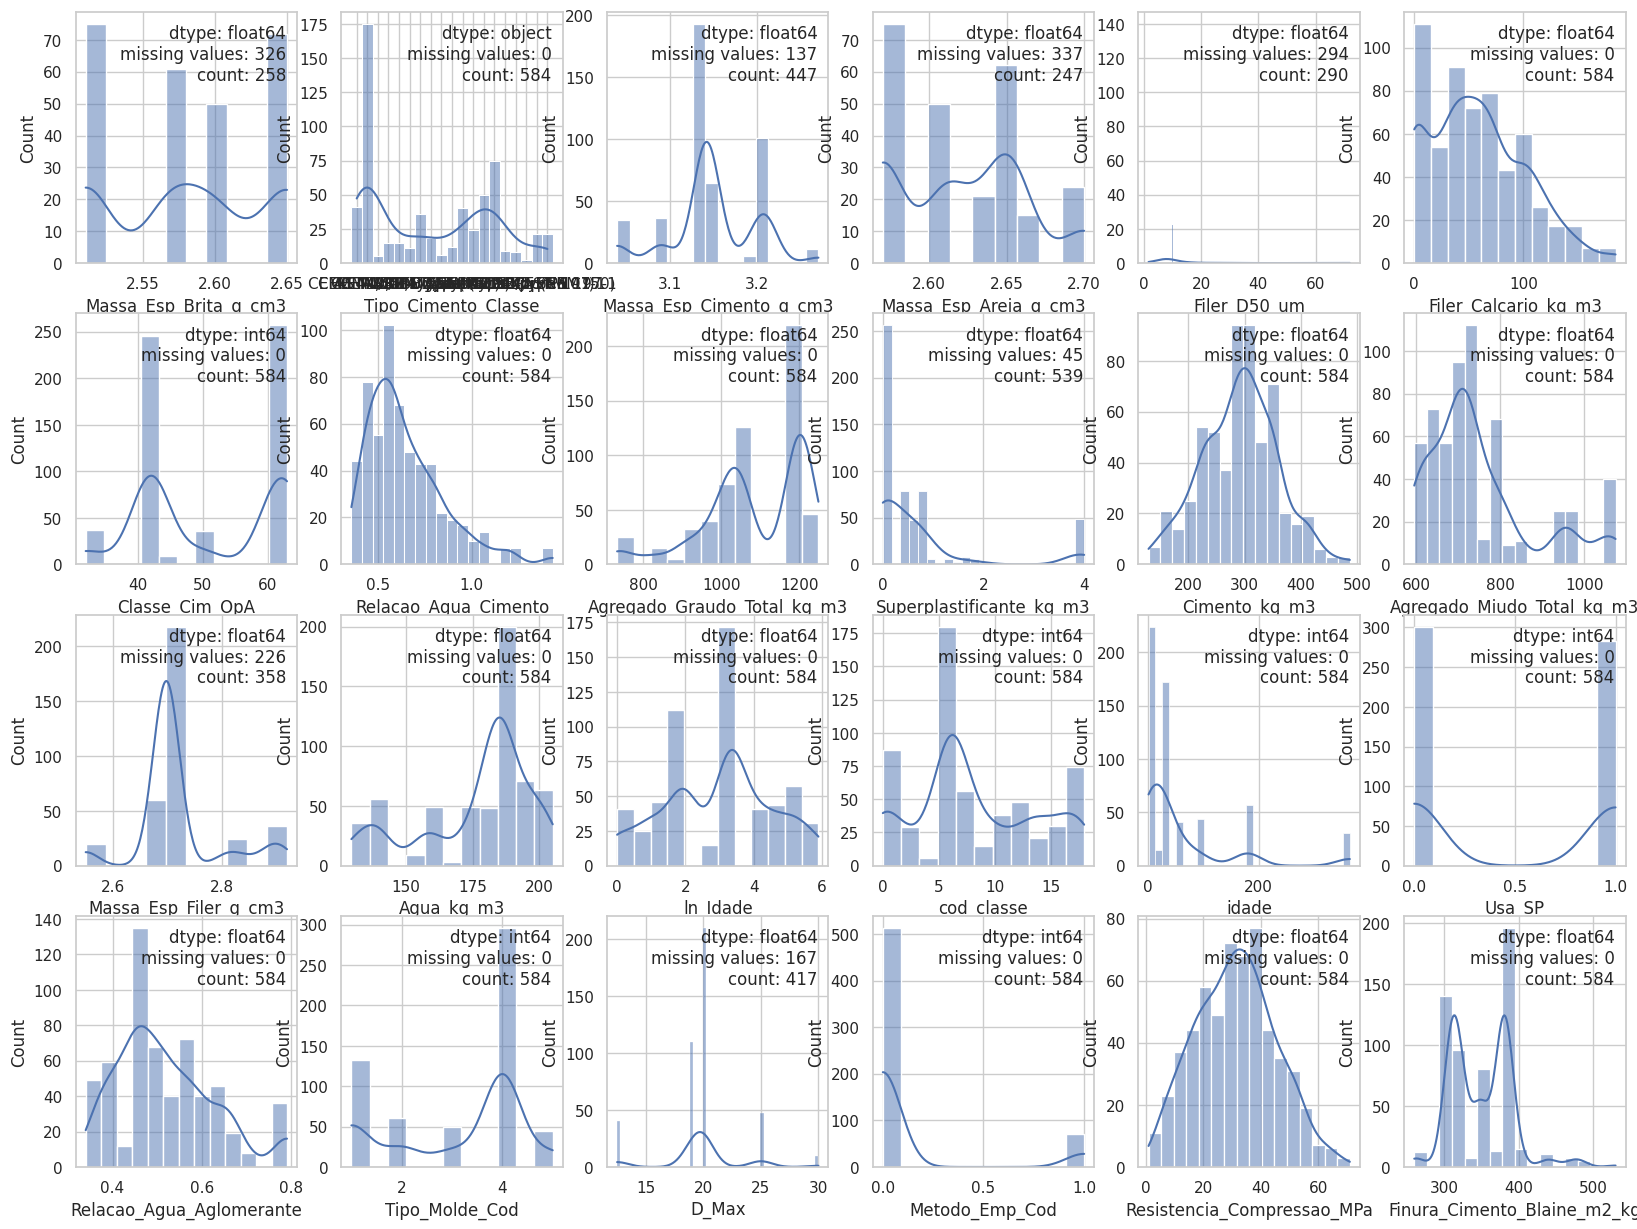

In [446]:
columns = set(df_resistencia.columns)
exclude = {'Autores/ano', 'ID_Mistura'}
columns -= exclude
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))
axes = axes.flatten()

for i, column in enumerate(columns):
    text = (f"dtype: {df_resistencia[column].dtype}\n"
            f"missing values: {df_resistencia[column].isnull().sum()}\n"
            f"count: {df_resistencia[column].count()}")
    axes[i].text(0.95, 0.95, text, transform=axes[i].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df_resistencia[column], ax=axes[i], kde=True)

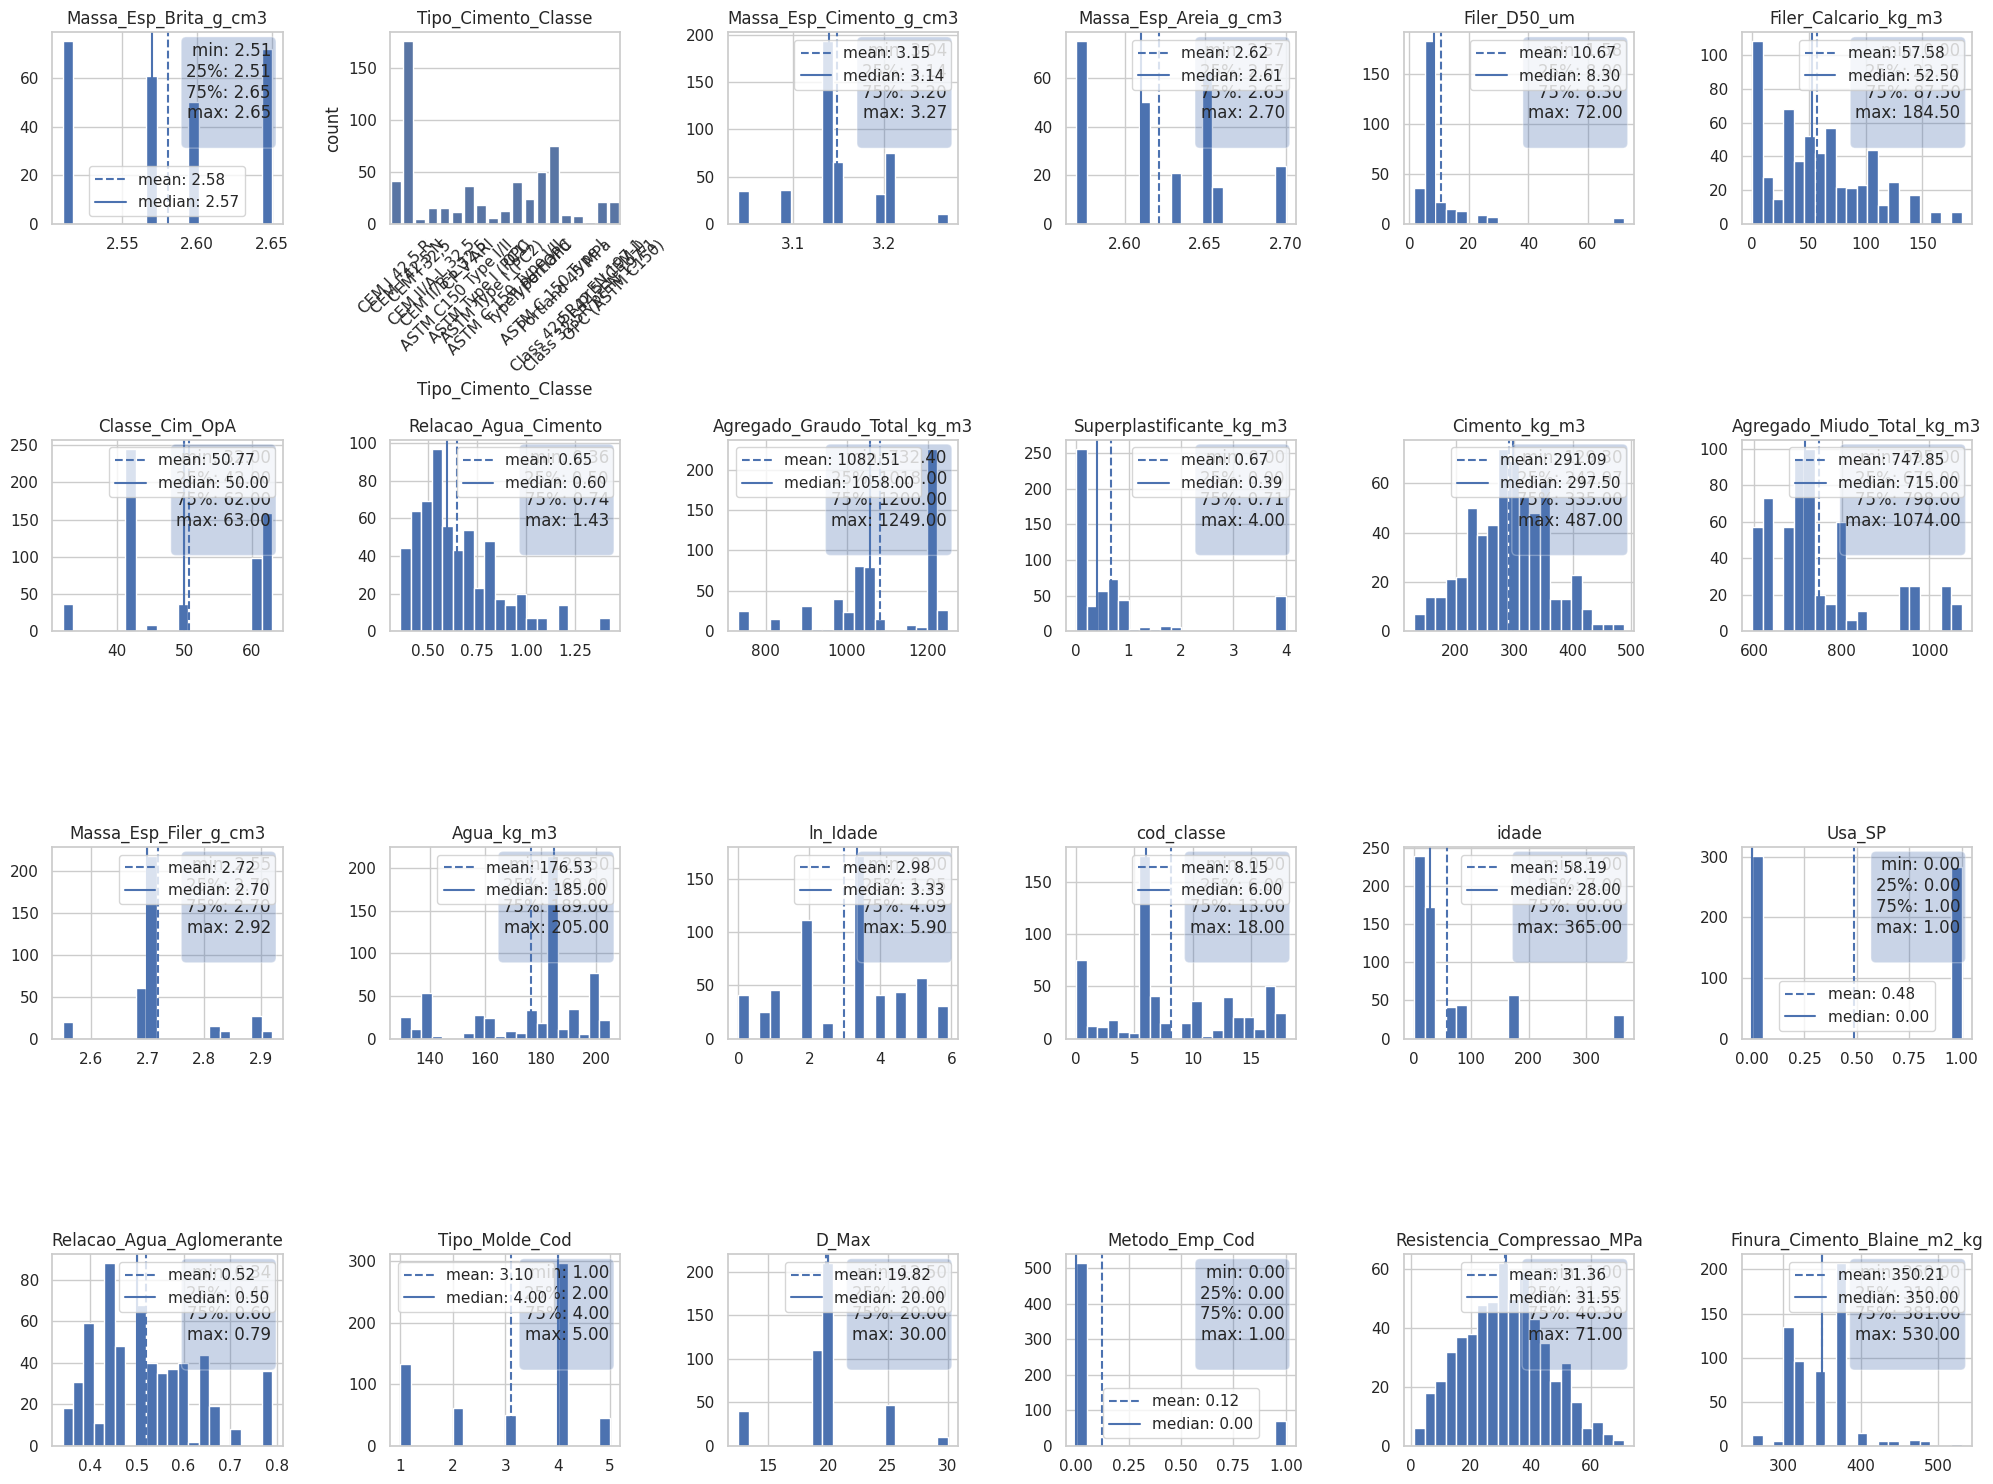

In [447]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    ax.hist(data, bins=20)
    
    stats = data.describe()
    
    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")
    
    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )
    
    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

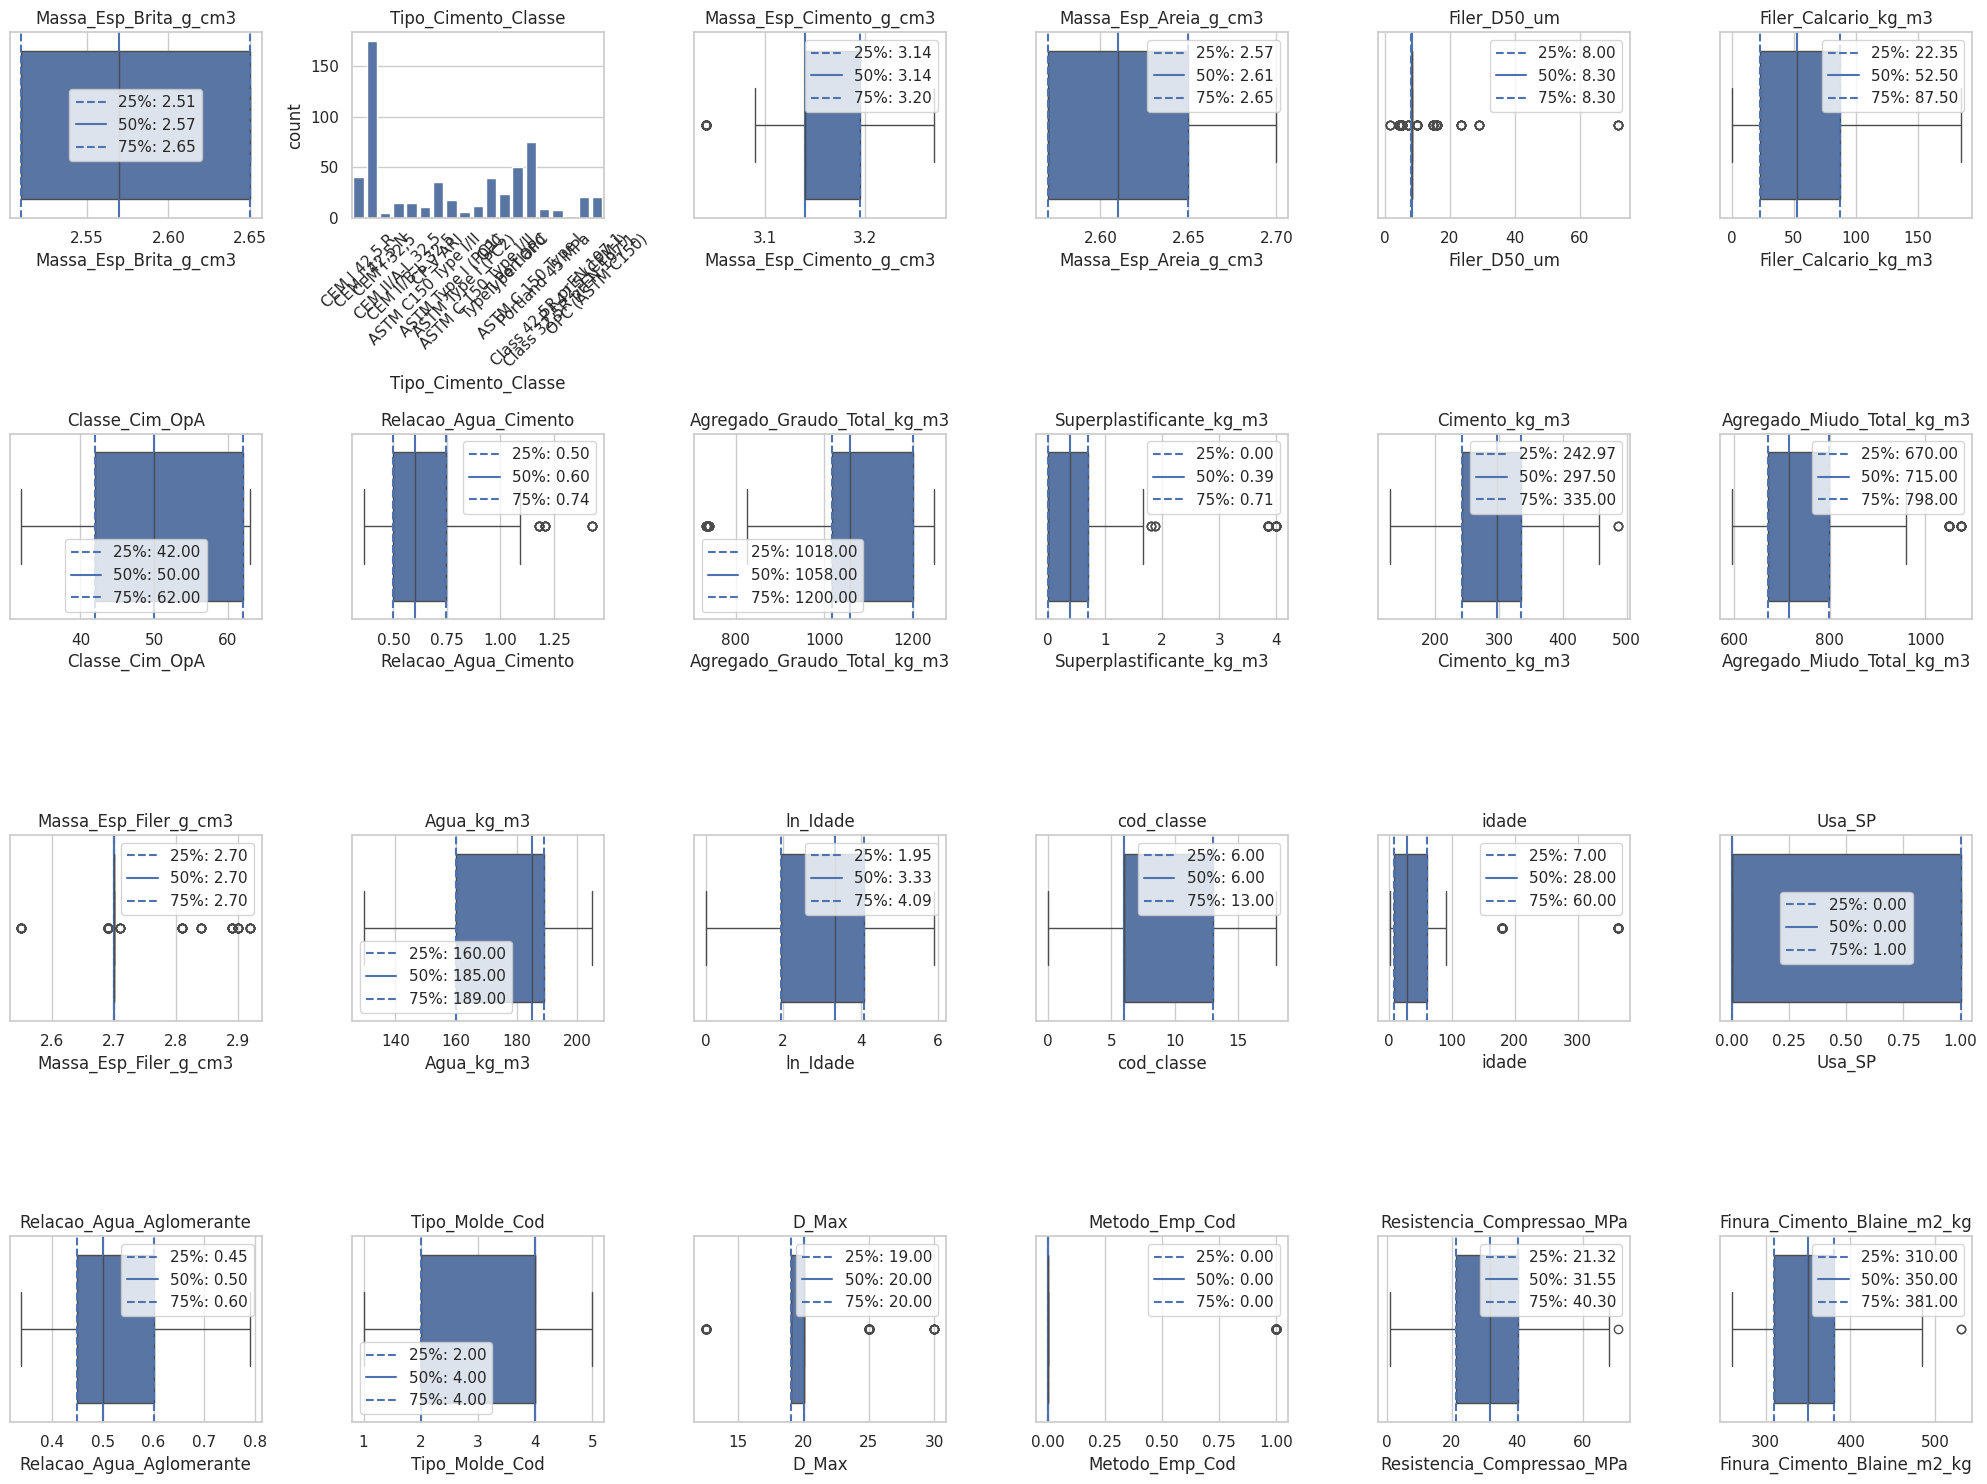

In [448]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    sns.boxplot(x=data, ax=ax)
    
    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
    ax.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [449]:
# Removendo coluna 'idade' de forma efetiva
df_resistencia.drop(columns=['idade'], inplace=True)

In [450]:
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 15 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  584 non-null    object 
 1   ID_Mistura                   584 non-null    object 
 2   Tipo_Cimento_Classe          584 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      447 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  584 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        247 non-null    float64
 7   Massa_Esp_Brita_g_cm3        258 non-null    float64
 8   Cimento_kg_m3                584 non-null    float64
 9   Filer_Calcario_kg_m3         584 non-null    float64
 10  Agua_kg_m3                   584 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   584 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  584 non-null    float64
 13  Superplastificante_kg_m3

In [451]:
# 1. Definindo as colunas do "DNA da Resistência"
colunas_cluster_original = [
    'Classe_Cim_OpA', 
    'Finura_Cimento_Blaine_m2_kg',
    'Relacao_Agua_Cimento',
    'Cimento_kg_m3'
]

# Separando apenas os dados que o HDBSCAN vai "enxergar"
X_cluster = df_resistencia[colunas_cluster_original].copy()

# 2. Padronização (Obrigatório para algoritmos de distância)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# min_cluster_size: O tamanho MÍNIMO para um grupo ser considerado uma "família". 
# (Ex: se colocar 15, qualquer grupo com menos de 15 traços parecidos é considerado anomalia/ruído)
hdbscan_modelo = HDBSCAN(
    min_cluster_size=5,     # A SALVAÇÃO: Permite que famílias raras (como o CEM I 32,5) sobrevivam
    min_samples=2,          # A LENIÊNCIA: Como min_cluster_size caiu, diminuir o min_samples impede que o modelo crie clusters demais. Ele aceita que os pontos estejam um pouquinho mais espalhados.
    cluster_selection_epsilon=0.5, # O IMÃ: Como os dados estão em StandardScaler, uma distância de 0.5 ajuda a fundir aqueles cimentos com nomes diferentes, mas química igual.
    metric='euclidean'
)

# O HDBSCAN já treina e devolve os rótulos (-1 significa RUÍDO/OUTLIER)
df_resistencia['Cluster_ID'] = hdbscan_modelo.fit_predict(X_scaled)

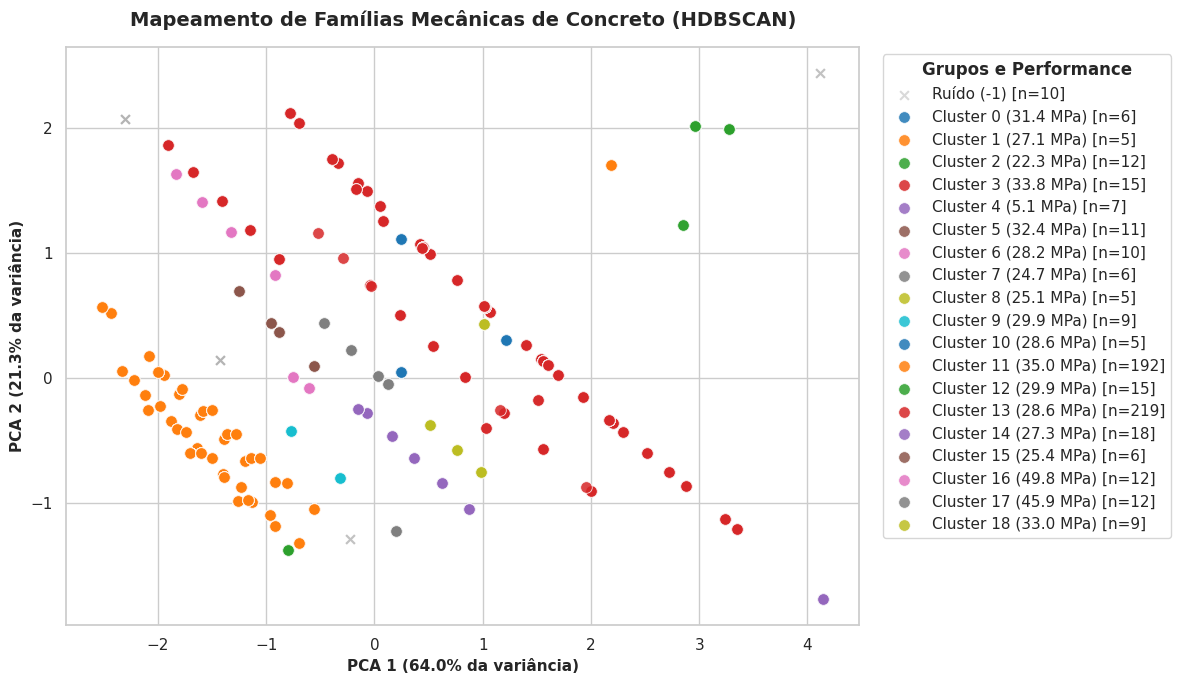

In [452]:
# 1. Redução para 2D e captura da variância explicada
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_resistencia.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

# Extraindo a importância de cada componente para os eixos
var_explicada = pca.explained_variance_ratio_ * 100

# 2. Configuração estética do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Criando uma paleta de cores viva apenas para os clusters válidos
clusters_validos = [c for c in sorted(df_plot["Cluster_ID"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["Cluster_ID"].unique()):
    subset = df_plot[df_plot["Cluster_ID"] == cluster]
    
    if cluster == -1:
        # Ruído fica em segundo plano: cinza, apagado e com marcador 'x'
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color="#A0A0A0", alpha=0.4, marker="x", s=40, 
            label=f"Ruído (-1) [n={len(subset)}]"
        )
    else:
        # Clusters válidos: cores marcantes e info da média de MPa na legenda
        media_mpa = subset["Resistencia_Compressao_MPa"].mean()
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
            label=f"Cluster {cluster} ({media_mpa:.1f} MPa) [n={len(subset)}]"
        )
        color_idx += 1

# 3. Customização de eixos com a variância do PCA
plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (HDBSCAN)", fontsize=14, fontweight='bold', pad=15)

# CORREÇÃO AQUI: Criamos a legenda e depois aplicamos o negrito no título dela
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold') 

plt.tight_layout()
plt.show()

# ==========================================
# 4. PÓS-PROCESSAMENTO
# ==========================================
df_resistencia_limpo = df_resistencia[df_resistencia['Cluster_ID'] != -1].copy()

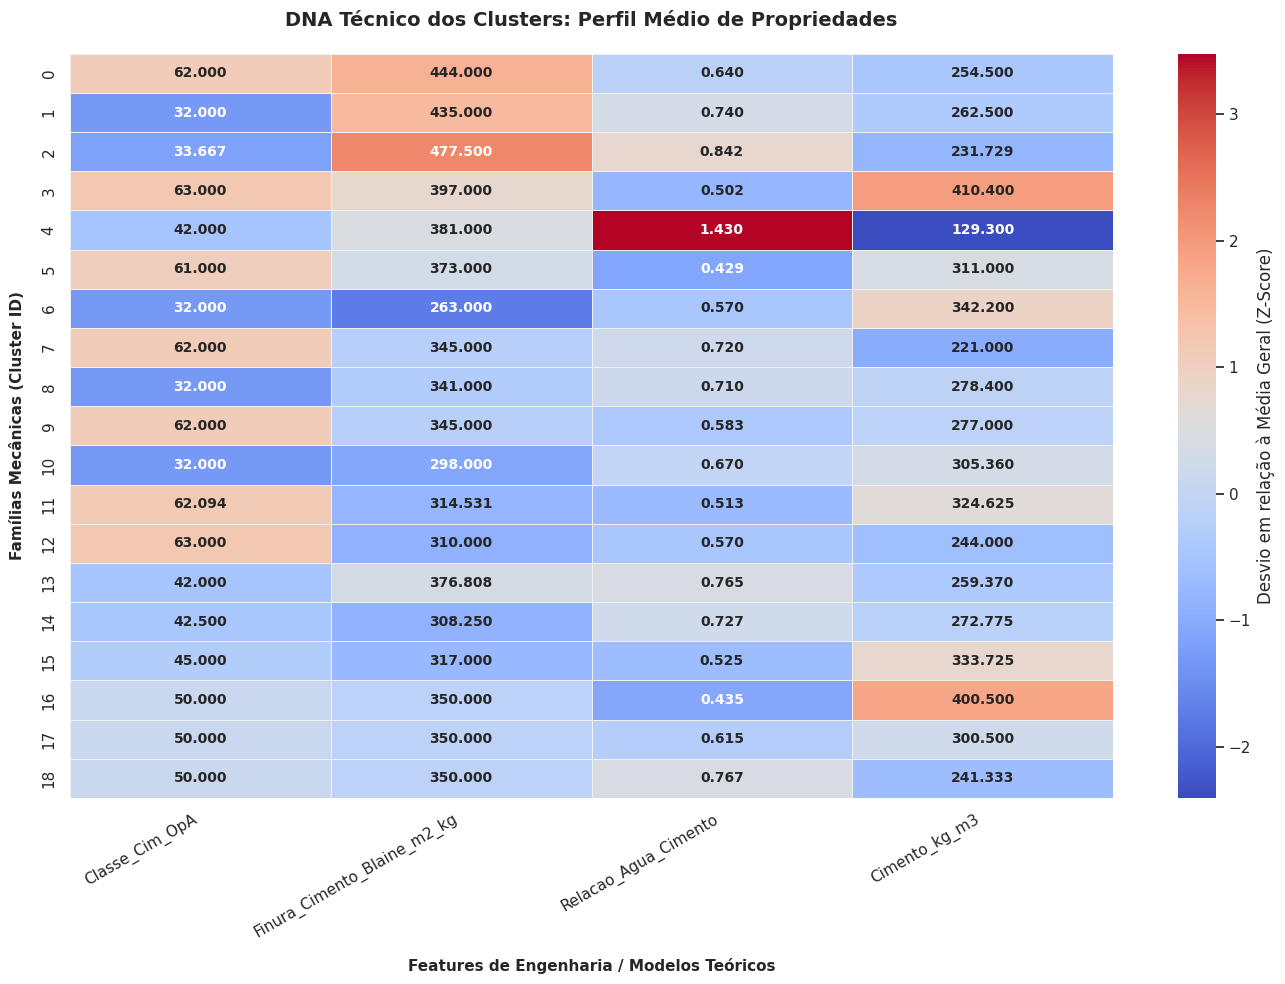

In [453]:
# 1. Calculando a média real por cluster
cluster_profile_raw = (
    df_resistencia_limpo
    .groupby("Cluster_ID")[colunas_cluster_original]
    .mean()
)

# 2. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 3. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(14, 10))

# 4. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled, 
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 5. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_58898/968386815.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


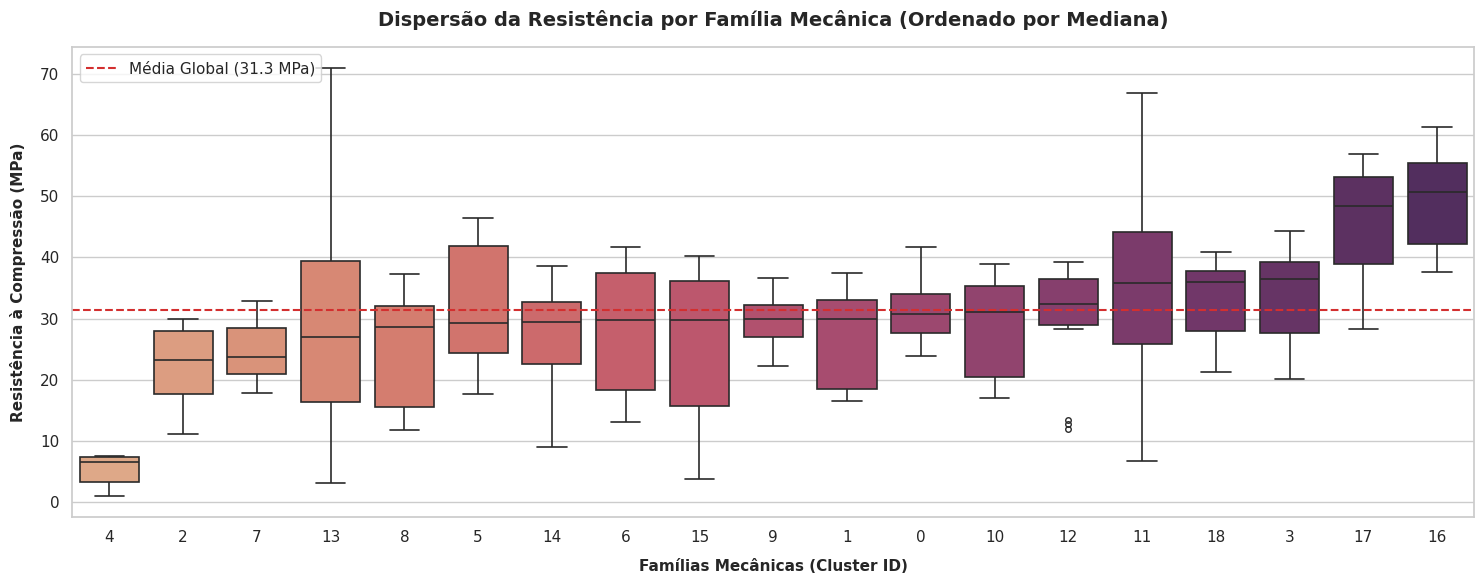

In [454]:
# 1. O TRUQUE DE MESTRE: Descobrir a ordem dos clusters baseada na MEDIANA da resistência
ordem_clusters = (
    df_resistencia_limpo
    .groupby("Cluster_ID")["Resistencia_Compressao_MPa"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6)) # Aumentamos a largura para acomodar os 18 grupos sem espremer

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_resistencia_limpo, 
    x="Cluster_ID", 
    y="Resistencia_Compressao_MPa",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_resistencia_limpo["Resistencia_Compressao_MPa"].mean()
plt.axhline(
    media_global, 
    color="#D32F2F", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Resistência por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Resistência à Compressão (MPa)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0) 

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [455]:
# Verificando se os clusters fazem sentido
analise_resistencia = df_resistencia_limpo.groupby('Cluster_ID')['Resistencia_Compressao_MPa'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_resistencia)

                 mean        std  count    min    max
Cluster_ID                                           
0           31.433333   6.310203      6  23.80  41.70
1           27.100000   9.188308      5  16.50  37.50
2           22.275000   6.460668     12  11.00  30.00
3           33.772667   8.110560     15  20.10  44.28
4            5.142857   2.703613      7   1.00   7.50
5           32.436364  10.948632     11  17.60  46.50
6           28.175000  10.364878     10  13.00  41.70
7           24.683333   5.722033      6  17.80  32.90
8           25.060000  10.944542      5  11.80  37.30
9           29.855556   4.714104      9  22.20  36.60
10          28.560000   9.463773      5  17.00  38.90
11          35.026823  12.508901    192   6.70  67.00
12          29.900000   9.595162     15  11.90  39.30
13          28.563973  15.374205    219   3.00  71.00
14          27.273889   7.685156     18   9.00  38.52
15          25.436667  14.808810      6   3.72  40.20
16          49.750000   7.80

In [456]:
df_resistencia_limpo["Usa_SP"] = df_resistencia_limpo["Usa_SP"].astype(bool)

In [457]:
df_resistencia_limpo.Usa_SP.dtype

dtype('bool')

In [458]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_resistencia_limpo[col] = df_resistencia_limpo.groupby('Cluster_ID')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_resistencia_limpo[col].mean()
    df_resistencia_limpo[col] = df_resistencia_limpo[col].fillna(media_global)
    
    # Verificação em tempo real
    nulos_restantes = df_resistencia_limpo[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_resistencia_limpo.loc[~df_resistencia_limpo['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_resistencia_limpo.loc[df_resistencia_limpo['Filer_Calcario_kg_m3'] == 0, 'Filer_D50_um'] = 0.0

df_resistencia_limpo['Massa_Esp_Cimento_kg_m3'] = df_resistencia_limpo['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Areia_kg_m3'] =  df_resistencia_limpo['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Brita_kg_m3'] = df_resistencia_limpo['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Filer_kg_m3'] = df_resistencia_limpo['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_resistencia_limpo['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_resistencia_limpo['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_resistencia_limpo['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_resistencia_limpo['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.


In [459]:
# Dicionário de Mapeamento do Coeficiente 's' do fib Model Code
# Baseado na norma europeia (EN 197-1), ASTM (C150) e brasileira
mapa_coeficiente_s = {
    # s = 0.20 (Rápido / Alta Resistência Inicial)
    'CP-V ARI': 0.20,
    'CEM I 42,5 R': 0.20,
    'Class 42.5R prEN 197-1': 0.20,
    'Portland 45 MPa': 0.20,

    # s = 0.25 (Normal / OPC Tradicional)
    'CEM I 42,5 N': 0.25,
    'ASTM C150 Type I/II': 0.25,
    'ASTM Type I (PC1)': 0.25,
    'ASTM Type I (PC2)': 0.25,
    'ASTM C 150 Type I/II': 0.25,
    'ASTM C 150 Type I': 0.25,
    'OPC': 0.25,
    'Type I Portland': 0.25,
    'Type I OPC': 0.25,
    'OPC (ASTM C150)': 0.25,
    'P,I 42,5 (CEM I)': 0.25, 

    # s = 0.38 (Lento / Baixa classe ou com adições como Fíler Calcário - L)
    'CEM I 32,5': 0.38,
    'CEM II/A-L 32,5': 0.38, 
    'CEM II/B-L 32,5': 0.38
}

In [460]:
# ==========================================
# FEATURE ENGINEERING - CONCRETE COMPRESSIVE STRENGTH
# ==========================================

EPS = np.finfo(float).eps

# ==========================================
# 1. CÁLCULO DE VOLUMES ABSOLUTOS
# ==========================================
print("\n" + "=" * 50)
print("1. VOLUMES ABSOLUTOS")
print("=" * 50)

df_resistencia_limpo['vol_cimento'] = pd.to_numeric(df_resistencia_limpo['Cimento_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Cimento_kg_m3']
df_resistencia_limpo['vol_agua'] = pd.to_numeric(df_resistencia_limpo['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_resistencia_limpo['vol_filer'] = pd.to_numeric(df_resistencia_limpo['Filer_Calcario_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Filer_kg_m3']
df_resistencia_limpo['vol_areia'] = pd.to_numeric(df_resistencia_limpo['Agregado_Miudo_Total_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Areia_kg_m3']
df_resistencia_limpo['vol_brita'] = pd.to_numeric(df_resistencia_limpo['Agregado_Graudo_Total_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Brita_kg_m3']
df_resistencia_limpo['vol_sp'] = pd.to_numeric(df_resistencia_limpo['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 2. FECHAMENTO VOLUMÉTRICO E POROSIDADE
# ==========================================
print("\n" + "=" * 50)
print("2. FECHAMENTO VOLUMÉTRICO E POROSIDADE")
print("=" * 50)

# Volume total de materiais
df_resistencia_limpo['volume_materiais'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_agua'] +
    df_resistencia_limpo['vol_filer'] +
    df_resistencia_limpo['vol_areia'] +
    df_resistencia_limpo['vol_brita'] +
    df_resistencia_limpo['vol_sp']
)

# Ar aprisionado
df_resistencia_limpo['vol_ar_aprisionado'] = (
    1.0 - df_resistencia_limpo['volume_materiais']
).clip(lower=0)

# Porosidade e índice de vazios
df_resistencia_limpo['porosidade_volumetrica_inicial'] = (
    df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado']
)

df_resistencia_limpo['vol_solidos_totais'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_filer'] +
    df_resistencia_limpo['vol_areia'] +
    df_resistencia_limpo['vol_brita']
)

df_resistencia_limpo['indice_vazios'] = (
    df_resistencia_limpo['porosidade_volumetrica_inicial'] /
    df_resistencia_limpo['vol_solidos_totais'].clip(lower=EPS)
)

# ==========================================
# 3. ESTRUTURA DO CONCRETO
# ==========================================
print("\n" + "=" * 50)
print("3. ESTRUTURA DO CONCRETO")
print("=" * 50)

# Volumes de agregados e pasta
df_resistencia_limpo['vol_agregados'] = (
    df_resistencia_limpo['vol_areia'] + df_resistencia_limpo['vol_brita']
)

df_resistencia_limpo['vol_pasta'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_agua'] +
    df_resistencia_limpo['vol_filer']
)

df_resistencia_limpo['vol_po_total'] = (
    df_resistencia_limpo['vol_cimento'] + df_resistencia_limpo['vol_filer']
)

# Proporções
df_resistencia_limpo['pasta_agregado'] = (
    df_resistencia_limpo['vol_pasta'] /
    df_resistencia_limpo['vol_agregados'].clip(lower=EPS)
)

df_resistencia_limpo['fracao_agregados'] = df_resistencia_limpo['vol_agregados']  # Já está em base 1.0

# ==========================================
# 4. RELAÇÕES DE MASSA E FINOS
# ==========================================
print("\n" + "=" * 50)
print("4. RELAÇÕES DE MASSA E FINOS")
print("=" * 50)

# Aglomerante total
df_resistencia_limpo['aglomerante_total'] = (
    df_resistencia_limpo['Cimento_kg_m3'] + df_resistencia_limpo['Filer_Calcario_kg_m3']
)

# Relação água/cimento (inversa)
df_resistencia_limpo['inv_a_c'] = (
    1.0 / df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# Fator água/pó (volumétrico)
df_resistencia_limpo['fator_agua_po'] = (
    df_resistencia_limpo['vol_agua'] /
    df_resistencia_limpo['vol_po_total'].clip(lower=EPS)
)

# Proporção de finos
df_resistencia_limpo['finos_total'] = (
    df_resistencia_limpo['Filer_Calcario_kg_m3'] /
    df_resistencia_limpo['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia_limpo['taxa_filer_inerte'] = (
    df_resistencia_limpo['Filer_Calcario_kg_m3'] /
    df_resistencia_limpo['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 5. SUPERPLASTIFICANTE
# ==========================================
print("\n" + "=" * 50)
print("5. SUPERPLASTIFICANTE")
print("=" * 50)

df_resistencia_limpo['taxa_sp_cimento'] = (
    df_resistencia_limpo['Superplastificante_kg_m3'] /
    df_resistencia_limpo['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia_limpo['taxa_sp_aglomerante'] = (
    df_resistencia_limpo['Superplastificante_kg_m3'] /
    df_resistencia_limpo['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 6. GRANULOMETRIA
# ==========================================
print("\n" + "=" * 50)
print("6. GRANULOMETRIA")
print("=" * 50)

df_resistencia_limpo['range_granulometrico'] = (
    (df_resistencia_limpo['D_Max'] * 1000) /
    (df_resistencia_limpo['Filer_D50_um'] + EPS)
)

# ==========================================
# 7. FEATURES TEMPORAIS BÁSICAS
# ==========================================
print("\n" + "=" * 50)
print("7. FEATURES TEMPORAIS BÁSICAS")
print("=" * 50)

# Idade em dias
idade_dias = np.exp(df_resistencia_limpo['ln_Idade'])

# Interação idade × a/c
df_resistencia_limpo['idade_fator_agua'] = (
    df_resistencia_limpo['ln_Idade'] /
    df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 8. MODELO DE FÉRET
# ==========================================
print("\n" + "=" * 50)
print("8. MODELO DE FÉRET")
print("=" * 50)

# Parâmetro de Féret básico
df_resistencia_limpo['parametro_feret'] = (
    df_resistencia_limpo['vol_cimento'] /
    (
        df_resistencia_limpo['vol_cimento'] +
        df_resistencia_limpo['vol_agua'] +
        df_resistencia_limpo['vol_ar_aprisionado']
    ).clip(lower=EPS)
) ** 2

# Interação com idade
df_resistencia_limpo['idade_feret'] = (
    df_resistencia_limpo['ln_Idade'] * df_resistencia_limpo['parametro_feret']
)

# Féret corrigido por condições de contorno (CBC)
vazios_agregados_estimado = df_resistencia_limpo['vol_agregados'] * 0.30

df_resistencia_limpo['saturacao_pasta'] = (
    df_resistencia_limpo['vol_pasta'] / vazios_agregados_estimado.clip(lower=EPS)
)

saturacao_pasta_mask = df_resistencia_limpo['saturacao_pasta'].clip(upper=1.0)

df_resistencia_limpo['qualidade_adensamento'] = np.exp(-df_resistencia_limpo['vol_ar_aprisionado'] * 50)

df_resistencia_limpo['fator_resistencia_rocha'] = (
        (df_resistencia_limpo['Massa_Esp_Brita_kg_m3'] - 2400).clip(lower=0) / (3000 - 2400)
    ).clip(upper=1.0)

df_resistencia_limpo['indice_conformidade_feret'] = (
    saturacao_pasta_mask * 
    df_resistencia_limpo['qualidade_adensamento'] * 
    df_resistencia_limpo['fator_resistencia_rocha']
)

df_resistencia_limpo['feret_corrigido_contorno'] = (
    df_resistencia_limpo['parametro_feret'] * df_resistencia_limpo['indice_conformidade_feret']
)

# O denominador do Féret Modificado é o volume total da pasta real
vol_pasta_real = (
    df_resistencia_limpo['vol_cimento'] + 
    df_resistencia_limpo['vol_filer'] + 
    df_resistencia_limpo['vol_agua'] + 
    df_resistencia_limpo['vol_ar_aprisionado']
).clip(lower=EPS)

# Criamos uma lista de fatores 'k' para testar (0.0 seria o Féret clássico ignorando o fíler)
fatores_k = [0.05, 0.10, 0.15, 0.20]

for k in fatores_k:
    nome_coluna = f'parametro_feret_filer_k{int(k*100)}'
    
    # Numerador: Volume Equivalente (Cimento + k * Fíler)
    vol_equivalente = df_resistencia_limpo['vol_cimento'] + (k * df_resistencia_limpo['vol_filer'])
    
    # A equação de Féret Modificada
    df_resistencia_limpo[nome_coluna] = (vol_equivalente / vol_pasta_real) ** 2
    
    # Criamos também a interação com o tempo (Cinética) para cada versão
    df_resistencia_limpo[f'idade_{nome_coluna}'] = df_resistencia_limpo['ln_Idade'] * df_resistencia_limpo[nome_coluna]

# ==========================================
# 9. CINÉTICA DE HIDRATAÇÃO
# ==========================================
print("\n" + "=" * 50)
print("9. CINÉTICA DE HIDRATAÇÃO")
print("=" * 50)

df_resistencia_limpo['potencial_reativo_tempo'] = (
    df_resistencia_limpo['ln_Idade'] * (df_resistencia_limpo['Finura_Cimento_Blaine_m2_kg'] / 1000)
)

df_resistencia_limpo['cinetica_real'] = (
    df_resistencia_limpo['potencial_reativo_tempo'] /
    df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 10. MODELO DE POWERS
# ==========================================
print("\n" + "=" * 50)
print("10. MODELO DE POWERS")
print("=" * 50)

# Baseado em massa
df_resistencia_limpo['pow_gel_space_mass'] = 0.68 / (df_resistencia_limpo['Relacao_Agua_Cimento'] + 0.32)

# Baseado em volume (com ar aprisionado)
df_resistencia_limpo['pow_gel_space_vol'] = (
    (2.06 * df_resistencia_limpo['vol_cimento']) /
    (df_resistencia_limpo['vol_cimento'] + df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado'])
)

# Lei cúbica de Powers
df_resistencia_limpo['pow_cubo_vol'] = df_resistencia_limpo['pow_gel_space_vol'] ** 3

# Interação temporal
df_resistencia_limpo['pow_interacao_tempo'] = (
    df_resistencia_limpo['pow_cubo_vol'] * df_resistencia_limpo['ln_Idade']
)

# Razão Powers/Féret
df_resistencia_limpo['razao_powers_feret'] = (
    df_resistencia_limpo['pow_gel_space_vol'] / df_resistencia_limpo['parametro_feret']
)

# ==========================================
# 11. MODELO DE RYSHKEWITCH
# ==========================================
print("\n" + "=" * 50)
print("11. MODELO DE RYSHKEWITCH")
print("=" * 50)

B_empirico = 5.0

# Porosidade real (considerando ar)
porosidade_real = (
    (df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado']) /
    df_resistencia_limpo['volume_materiais']
)

# Ryshkewitch inicial
df_resistencia_limpo['ryshkewitch_inicial'] = np.exp(-B_empirico * df_resistencia_limpo['porosidade_volumetrica_inicial'])

# Ryshkewitch real
df_resistencia_limpo['ryshkewitch_real'] = np.exp(-B_empirico * porosidade_real)

# Ryshkewitch cinético
porosidade_atual_estimada = df_resistencia_limpo['porosidade_volumetrica_inicial'] / (df_resistencia_limpo['ln_Idade'] + 1)
df_resistencia_limpo['ryshkewitch_cinetico'] = np.exp(-B_empirico * porosidade_atual_estimada)

# Linearização logarítmica
df_resistencia_limpo['ryshkewitch_linearizado'] = -df_resistencia_limpo['porosidade_volumetrica_inicial']

# ==========================================
# 12. MODELO DE HASSELMANN
# ==========================================
print("\n" + "=" * 50)
print("12. MODELO DE HASSELMANN")
print("=" * 50)

K_HASSELMAN = 3.0

# Hasselmann inicial
df_resistencia_limpo['hasselman_fator_inicial'] = 1 - (K_HASSELMAN * df_resistencia_limpo['porosidade_volumetrica_inicial'])

# Hasselmann real
df_resistencia_limpo['hasselman_fator_real'] = 1 - (K_HASSELMAN * porosidade_real)

# Hasselmann cinético
porosidade_cinetica = df_resistencia_limpo['porosidade_volumetrica_inicial'] / (df_resistencia_limpo['ln_Idade'] + 1)
df_resistencia_limpo['hasselman_cinetico'] = 1 - (K_HASSELMAN * porosidade_cinetica)

# Resiliência
df_resistencia_limpo['hasselman_resiliencia_agua'] = (
    df_resistencia_limpo['hasselman_fator_real'] / df_resistencia_limpo['vol_agua']
)

# ==========================================
# 13. MODELO DE SCHILLER
# ==========================================
print("\n" + "=" * 50)
print("13. MODELO DE SCHILLER")
print("=" * 50)

P_CR = 0.50

# Schiller inicial
p_seguro_inicial = df_resistencia_limpo['porosidade_volumetrica_inicial'].clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_inicial'] = np.log(P_CR / p_seguro_inicial)

# Schiller real
p_seguro_real = porosidade_real.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_real'] = np.log(P_CR / p_seguro_real)

# Schiller cinético
porosidade_cinetica_schiller = porosidade_real / (df_resistencia_limpo['ln_Idade'] + 1)
p_seguro_cinetico = porosidade_cinetica_schiller.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_cinetico'] = np.log(P_CR / p_seguro_cinetico)

# Margem de colapso
df_resistencia_limpo['margem_colapso_schiller'] = P_CR - porosidade_real

# ==========================================
# 14. MODELO ACI (AMERICANO)
# ==========================================
print("\n" + "=" * 50)
print("14. MODELO ACI")
print("=" * 50)

t_dias = np.exp(df_resistencia_limpo['ln_Idade'])

# Fator temporal ACI 209R
df_resistencia_limpo['aci_209_fator_tempo'] = t_dias / (4.0 + 0.85 * t_dias)

# Estimativa base ACI 211 (28 dias)
df_resistencia_limpo['aci_211_base_28d'] = 96.0 / (4.0 ** df_resistencia_limpo['Relacao_Agua_Cimento'])

# Desvio
df_resistencia_limpo['aci_desvio_cimento'] = (
    df_resistencia_limpo['vol_cimento'] / (df_resistencia_limpo['aci_211_base_28d'] * df_resistencia_limpo['aci_209_fator_tempo'])
)

# ==========================================
# 15. MODELO FIB/ EUROCODE
# ==========================================
print("\n" + "=" * 50)
print("15. MODELO FIB/EUROCODE")
print("=" * 50)

# Coeficiente s
df_resistencia_limpo['s_fib'] = df_resistencia_limpo['Tipo_Cimento_Classe'].map(mapa_coeficiente_s)
df_resistencia_limpo['s_fib'] = df_resistencia_limpo.groupby('Cluster_ID')['s_fib'].transform(
    lambda x: x.fillna(x.mean())
)

# Fator temporal fib
t_dias_clip = np.exp(df_resistencia_limpo['ln_Idade']).clip(lower=1.0)
raiz_tempo = np.sqrt(28.0 / t_dias_clip)
df_resistencia_limpo['fib_fator_tempo'] = np.exp(df_resistencia_limpo['s_fib'] * (1 - raiz_tempo))

# Núcleo de Bolomey
df_resistencia_limpo['bolomey_nucleo_linear'] = (df_resistencia_limpo['inv_a_c'] - 0.5).clip(lower=0)

# Estimativa completa fib
df_resistencia_limpo['fib_estimativa_base'] = (
    df_resistencia_limpo['bolomey_nucleo_linear'] * df_resistencia_limpo['fib_fator_tempo']
)

# ==========================================
# 16. INTERAÇÕES ADICIONAIS
# ==========================================
print("\n" + "=" * 50)
print("16. INTERAÇÕES ADICIONAIS")
print("=" * 50)

df_resistencia_limpo['pasta_agregado_fino'] = (
    df_resistencia_limpo['vol_pasta'] / df_resistencia_limpo['vol_areia'].clip(lower=EPS)
)

df_resistencia_limpo['densidade_matriz'] = (
    df_resistencia_limpo['vol_po_total'] /
    (df_resistencia_limpo['vol_po_total'] + df_resistencia_limpo['vol_agua']).clip(lower=EPS)
)

# ==========================================
# RESUMO FINAL
# ==========================================
print("\n" + "=" * 50)
print("FEATURE ENGINEERING CONCLUÍDO")
print("=" * 50)
print(f"Total de features criadas: {len(df_resistencia_limpo.columns)}")
print(f"Total de amostras: {len(df_resistencia_limpo)}")


1. VOLUMES ABSOLUTOS

2. FECHAMENTO VOLUMÉTRICO E POROSIDADE

3. ESTRUTURA DO CONCRETO

4. RELAÇÕES DE MASSA E FINOS

5. SUPERPLASTIFICANTE

6. GRANULOMETRIA

7. FEATURES TEMPORAIS BÁSICAS

8. MODELO DE FÉRET

9. CINÉTICA DE HIDRATAÇÃO

10. MODELO DE POWERS

11. MODELO DE RYSHKEWITCH

12. MODELO DE HASSELMANN

13. MODELO DE SCHILLER

14. MODELO ACI

15. MODELO FIB/EUROCODE

16. INTERAÇÕES ADICIONAIS

FEATURE ENGINEERING CONCLUÍDO
Total de features criadas: 94
Total de amostras: 574


In [461]:
df_resistencia_limpo.Tipo_Cimento_Classe.unique()

array(['CEM I 42,5 R', 'CEM I 42,5 N', 'CEM I 32,5', 'CEM II/A-L 32,5',
       'CEM II/B-L 32,5', 'ASTM C150 Type I/II', 'CP-V ARI',
       'ASTM Type I (PC1)', 'ASTM Type I (PC2)', 'ASTM C 150 Type I/II',
       'OPC', 'Type I Portland', 'Type I OPC', 'ASTM C 150 Type I',
       'Portland 45 MPa', 'Class 42.5R prEN 197-1', 'P,I 42,5 (CEM I)',
       'OPC (ASTM C150)'], dtype=object)

In [462]:
columns = df_resistencia_limpo.columns
for col in columns:
    if df_resistencia_limpo[col].isna().sum() > 0:
        print(f"{col}: {df_resistencia_limpo[col].dtype}, Nulos: {df_resistencia_limpo[col].isna().sum()}")

In [463]:
exclude_columns = {'Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe'}

In [464]:
df_resistencia_limpo.columns

Index(['Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe',
       'Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'ln_Idade', 'Tipo_Molde_Cod', 'Metodo_Emp_Cod',
       'Usa_SP', 'Classe_Cim_OpA', 'Relacao_Agua_Aglomerante', 'Filer_D50_um',
       'D_Max', 'Resistencia_Compressao_MPa', 'cod_classe', 'Cluster_ID',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_cimento',
       'vol_agua', 'vol_filer', 'vol_areia', 'vol_brita', 'vol_sp',
       'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'fracao_agregados', 'aglomerante_total', 'inv_a_c', 'fator_agua_po',
       'finos_total', 'taxa_filer_iner

In [465]:
# 1. Definindo as colunas do "DNA da Resistência"
colunas_cluster_derivadas = [
    'pow_gel_space_vol',          # Teoria de Powers (Porosidade/Gel)
    'feret_corrigido_contorno',   # Teoria de Féret (Empacotamento)
    'fator_agua_po',              # Indicador de porosidade inicial da pasta
    'taxa_filer_inerte',          # Fator de substituição mineral
    'cinetica_real',              # Evolução temporal da hidratação
    'densidade_matriz'            # Compacidade da fase aglutinante
]

# Separando apenas os dados que o HDBSCAN vai "enxergar"
X_cluster = df_resistencia_limpo[colunas_cluster_derivadas].copy()

# 2. Padronização (Obrigatório para algoritmos de distância)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# min_cluster_size: O tamanho MÍNIMO para um grupo ser considerado uma "família". 
# (Ex: se colocar 15, qualquer grupo com menos de 15 traços parecidos é considerado anomalia/ruído)
hdbscan_modelo = HDBSCAN(
    min_cluster_size=5,     # A SALVAÇÃO: Permite que famílias raras (como o CEM I 32,5) sobrevivam
    min_samples=2,          # A LENIÊNCIA: Como min_cluster_size caiu, diminuir o min_samples impede que o modelo crie clusters demais. Ele aceita que os pontos estejam um pouquinho mais espalhados.
    cluster_selection_epsilon=0.5, # O IMÃ: Como os dados estão em StandardScaler, uma distância de 0.5 ajuda a fundir aqueles cimentos com nomes diferentes, mas química igual.
    metric='euclidean'
)

# O HDBSCAN já treina e devolve os rótulos (-1 significa RUÍDO/OUTLIER)
df_resistencia_limpo['Cluster_ID'] = hdbscan_modelo.fit_predict(X_scaled)


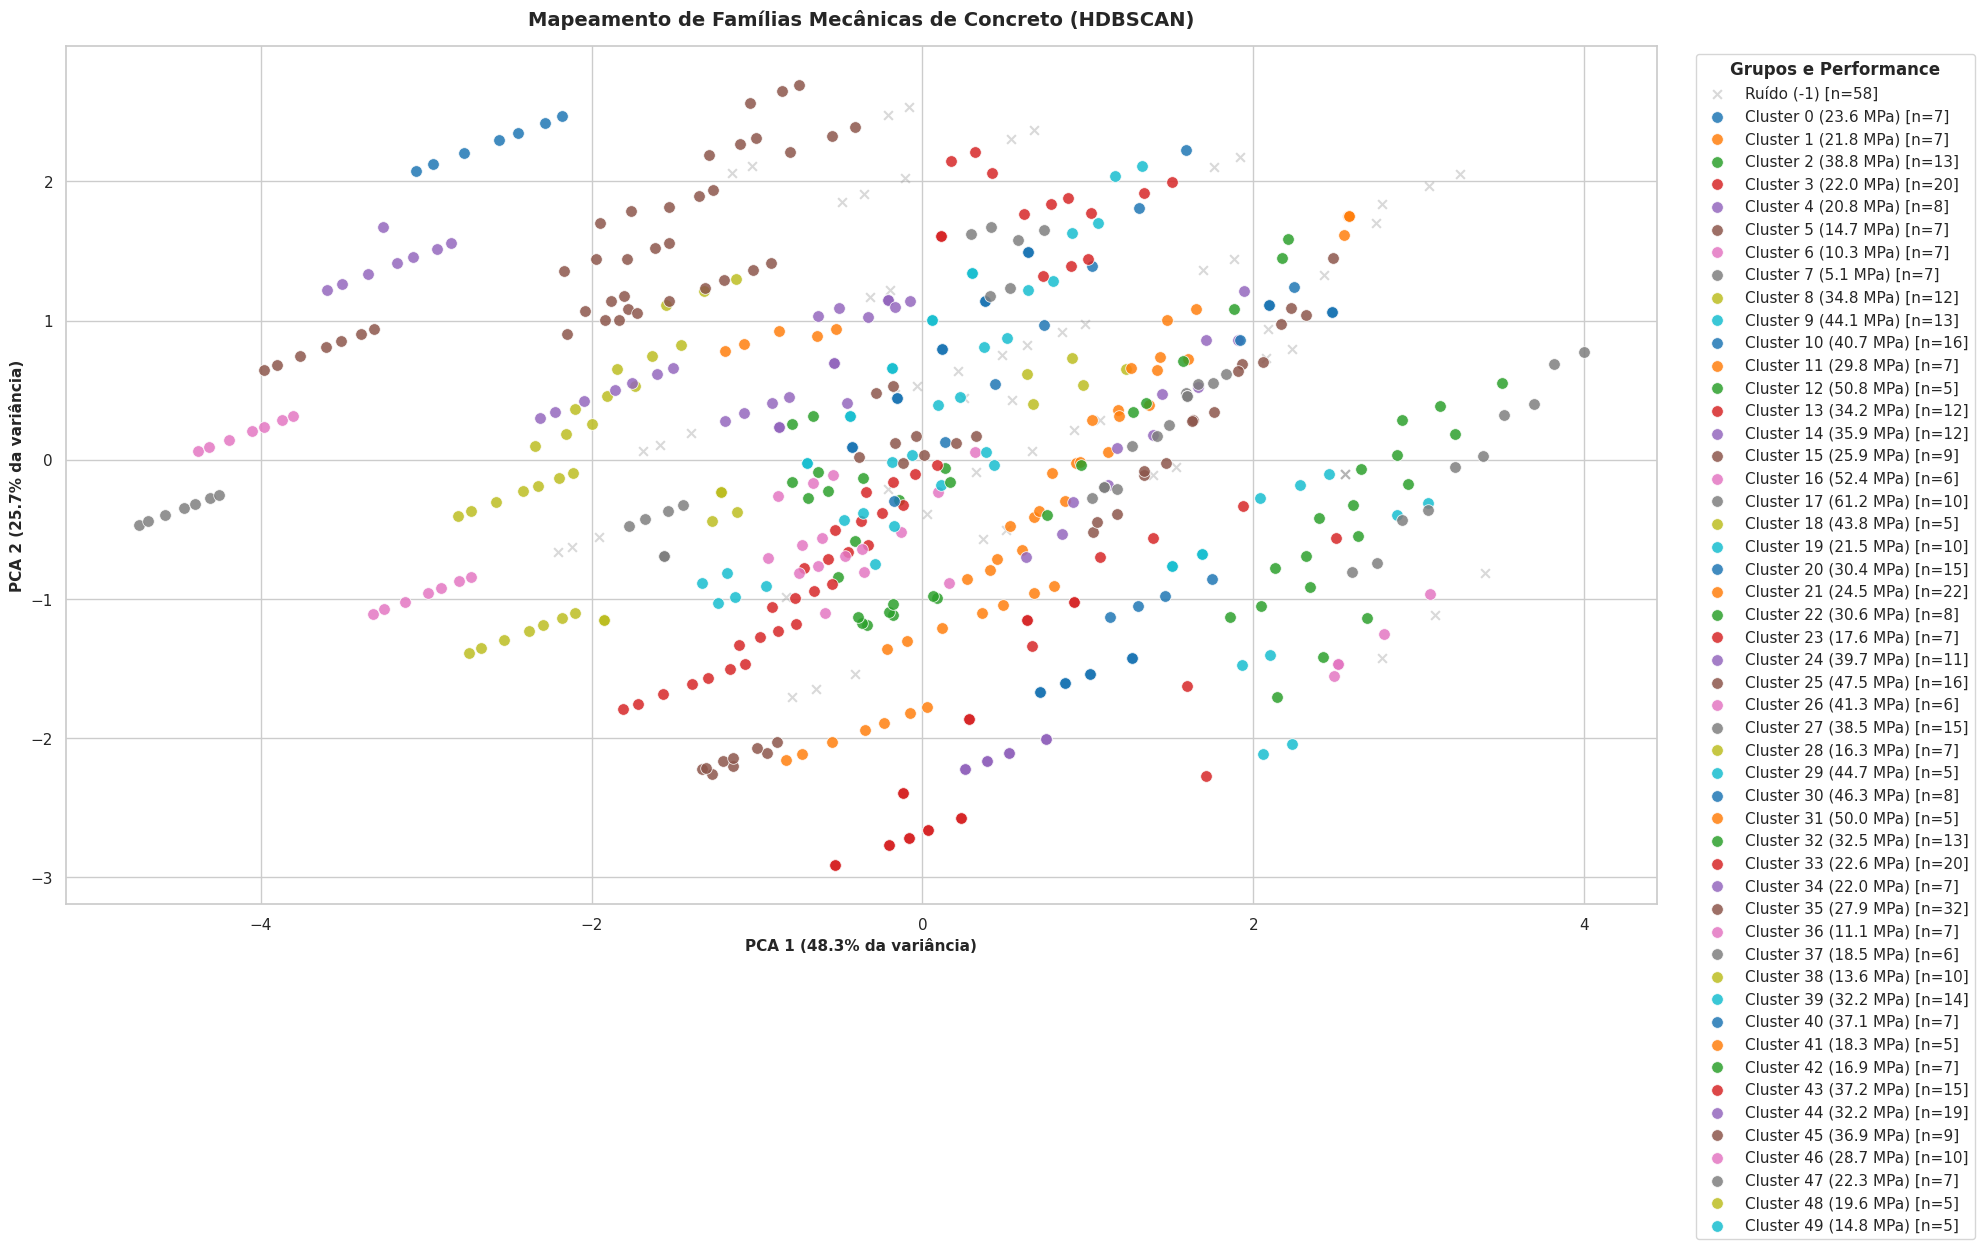

In [466]:
# 1. Redução para 2D e captura da variância explicada
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_resistencia_limpo.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

# Extraindo a importância de cada componente para os eixos
var_explicada = pca.explained_variance_ratio_ * 100

# 2. Configuração estética do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 12))

# Criando uma paleta de cores viva apenas para os clusters válidos
clusters_validos = [c for c in sorted(df_plot["Cluster_ID"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["Cluster_ID"].unique()):
    subset = df_plot[df_plot["Cluster_ID"] == cluster]
    
    if cluster == -1:
        # Ruído fica em segundo plano: cinza, apagado e com marcador 'x'
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color="#A0A0A0", alpha=0.4, marker="x", s=40, 
            label=f"Ruído (-1) [n={len(subset)}]"
        )
    else:
        # Clusters válidos: cores marcantes e info da média de MPa na legenda
        media_mpa = subset["Resistencia_Compressao_MPa"].mean()
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
            label=f"Cluster {cluster} ({media_mpa:.1f} MPa) [n={len(subset)}]"
        )
        color_idx += 1

# 3. Customização de eixos com a variância do PCA
plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (HDBSCAN)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold') 

plt.tight_layout()
plt.show()

# ==========================================
# 4. PÓS-PROCESSAMENTO
# ==========================================
df_resistencia_limpo = df_resistencia_limpo[df_resistencia_limpo['Cluster_ID'] != -1].copy()

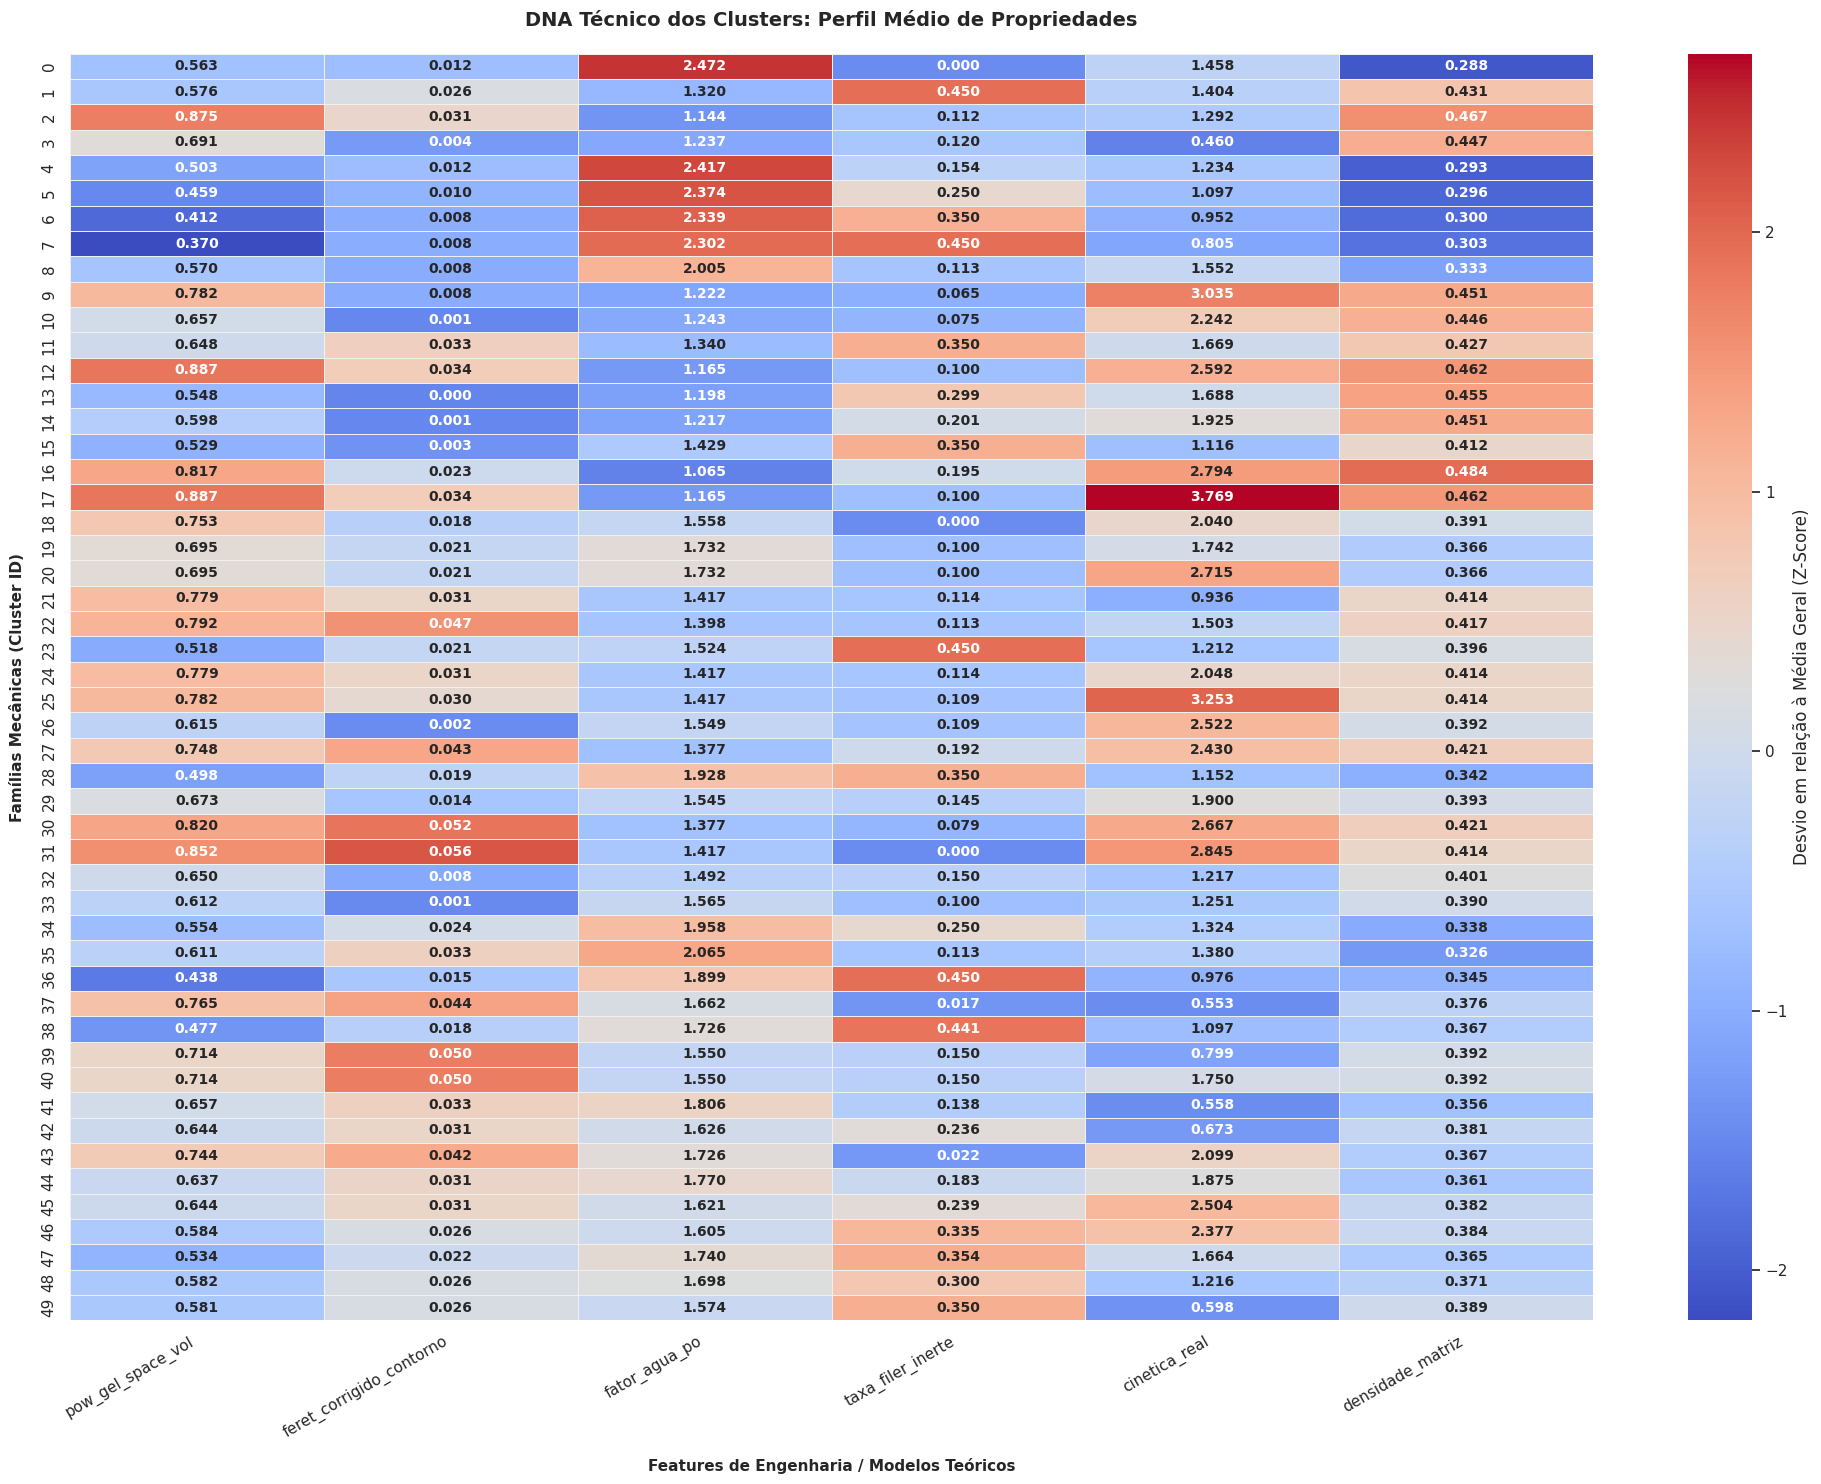

In [467]:
# 1. Filtrando o ruído para não distorcer as médias da população real
df_perfil = df_resistencia_limpo[df_resistencia_limpo['Cluster_ID'] != -1].copy()

# 2. Calculando a média real por cluster
cluster_profile_raw = (
    df_perfil
    .groupby("Cluster_ID")[colunas_cluster_derivadas]
    .mean()
)

# 3. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 4. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(20, 15))

# 5. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled, 
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 6. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_58898/3425588775.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


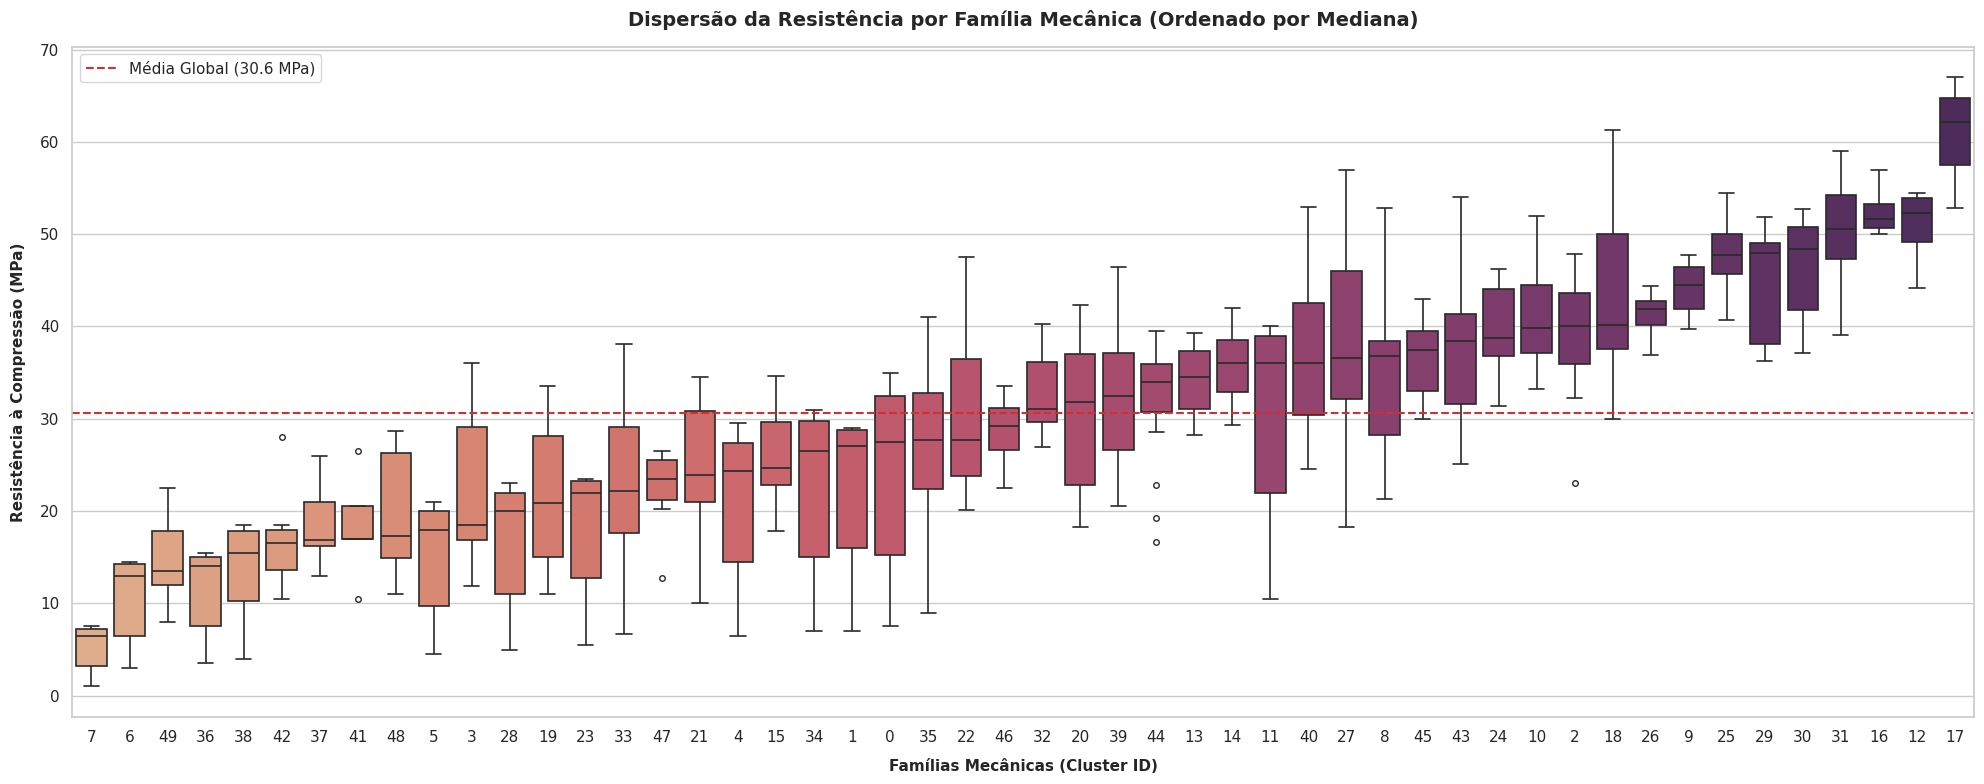

In [468]:
# 1. O TRUQUE DE MESTRE: Descobrir a ordem dos clusters baseada na MEDIANA da resistência
ordem_clusters = (
    df_resistencia_limpo
    .groupby("Cluster_ID")["Resistencia_Compressao_MPa"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_resistencia_limpo, 
    x="Cluster_ID", 
    y="Resistencia_Compressao_MPa",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_resistencia_limpo["Resistencia_Compressao_MPa"].mean()
plt.axhline(
    media_global, 
    color="#D32F2F", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Resistência por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Resistência à Compressão (MPa)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0) 

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [469]:
# Verificando se os clusters fazem sentido
analise_resistencia = df_resistencia_limpo.groupby('Cluster_ID')['Resistencia_Compressao_MPa'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_resistencia)

                 mean        std  count    min    max
Cluster_ID                                           
0           23.642857  11.014060      7   7.50  35.00
1           21.785714   9.236960      7   7.00  29.00
2           38.831538   6.930110     13  23.00  47.90
3           22.035000   8.119585     20  11.90  36.00
4           20.762500   8.801451      8   6.50  29.50
5           14.714286   6.713526      7   4.50  21.00
6           10.285714   4.940118      7   3.00  14.50
7            5.142857   2.703613      7   1.00   7.50
8           34.800000   8.292055     12  21.30  52.80
9           44.107692   2.842083     13  39.70  47.80
10          40.650000   5.034018     16  33.20  52.00
11          29.785714  12.185569      7  10.50  40.00
12          50.814000   4.220720      5  44.22  54.50
13          34.216667   3.930495     12  28.20  39.30
14          35.950000   4.020063     12  29.30  42.00
15          25.944444   5.633407      9  17.80  34.60
16          52.400000   2.60

In [470]:
df_resistencia_limpo.corr(method='spearman', numeric_only=True)['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
fib_estimativa_base,0.864451
pow_interacao_tempo,0.817307
idade_parametro_feret_filer_k5,0.806106
idade_parametro_feret_filer_k10,0.801240
...,...
pasta_agregado,0.024026
saturacao_pasta,0.024026
vol_solidos_totais,0.022555
Usa_SP,0.005160


In [471]:
# Verificando a sanidade das features de contorno de Féret
features_verificacao = ['vol_ar_aprisionado', 'saturacao_pasta', 'fator_resistencia_rocha']

print("--- DIAGNÓSTICO DE PENALIDADES (FÉRET) ---")
display(df_resistencia_limpo[features_verificacao].describe().round(4))

--- DIAGNÓSTICO DE PENALIDADES (FÉRET) ---


,vol_ar_aprisionado,saturacao_pasta,fator_resistencia_rocha
count,516.0000,516.0000,516.0000
mean,0.0157,1.3717,0.3029
std,0.0259,0.1576,0.0669
min,0.0000,1.0441,0.1833
25%,0.0000,1.2574,0.2475
50%,0.0000,1.3889,0.3333
75%,0.0245,1.4708,0.3333
max,0.0805,1.7937,0.4167


In [472]:
# Defina sua variável alvo (substitua pelo nome correto da sua coluna)
ALVO = 'Resistencia_Compressao_MPa'

# Colunas que envolvem o filler
whitelist_features = [
    'vol_cimento',
    'vol_filer',
    'Relacao_Agua_Aglomerante',
    'vol_sp'
    ]

# 1. Calcula a matriz de correlação de Spearman
corr_matrix = df_resistencia_limpo.corr(method='spearman', numeric_only=True).abs()

# 2. Pega a correlação de todas as features com o Alvo
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

# 3. Identifica pares altamente correlacionados (limite de 0.95)
limite_colinearidade = 0.99
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        
        # Ignora a comparação se uma delas for o Alvo
        if col_i == ALVO or col_j == ALVO:
            continue
            
        if corr_matrix.iloc[i, j] > limite_colinearidade:
            if col_i in whitelist_features and col_j in whitelist_features:
                continue
            elif col_i in whitelist_features and col_j not in whitelist_features:
                features_para_remover.add(col_j)
                continue
            elif col_j in whitelist_features and col_i not in whitelist_features:
                features_para_remover.add(col_i)
                continue

            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")
df_filtrado = df_resistencia_limpo.drop(columns=features_para_remover)

Features removidas por colinearidade: {'fator_resistencia_rocha', 'ryshkewitch_inicial', 'Filer_Calcario_kg_m3', 'aci_209_fator_tempo', 'parametro_feret_filer_k5', 'Superplastificante_kg_m3', 'Cimento_kg_m3', 'Agregado_Miudo_Total_kg_m3', 'saturacao_pasta', 'bolomey_nucleo_linear', 'ryshkewitch_real', 'inv_a_c', 'pow_gel_space_vol', 'fracao_agregados', 'taxa_filer_inerte', 'idade_feret', 'hasselman_fator_inicial', 'schiller_cinetico', 'hasselman_cinetico', 'razao_powers_feret', 'schiller_inicial', 'parametro_feret', 'qualidade_adensamento', 'fator_agua_po', 'idade_parametro_feret_filer_k15', 'parametro_feret_filer_k15', 'pow_cubo_vol', 'aci_211_base_28d', 'schiller_real', 'idade_parametro_feret_filer_k20', 'parametro_feret_filer_k10', 'vol_agua', 'idade_parametro_feret_filer_k10', 'pow_gel_space_mass', 'margem_colapso_schiller', 'taxa_sp_cimento', 'hasselman_fator_real', 'ryshkewitch_linearizado'}


In [473]:
df_filtrado.corr(method='spearman', numeric_only=True)['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
fib_estimativa_base,0.864451
pow_interacao_tempo,0.817307
idade_parametro_feret_filer_k5,0.806106
idade_fator_agua,0.797609
cinetica_real,0.771705
aci_desvio_cimento,0.644735
Relacao_Agua_Cimento,0.633623
parametro_feret_filer_k20,0.620374
vol_cimento,0.574330


In [474]:
df_filtrado.drop(columns=["ID_Mistura", "Tipo_Cimento_Classe"], inplace=True)

In [475]:
columns = df_filtrado.select_dtypes(include=['number']).columns

outliers_idx = {}
for column in columns:

    data = df_filtrado[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

aglomerante_total: 201 outliers
Massa_Esp_Filer_kg_m3: 159 outliers
s_fib: 114 outliers
vol_areia: 90 outliers
D_Max: 89 outliers
hasselman_resiliencia_agua: 89 outliers
range_granulometrico: 86 outliers
porosidade_volumetrica_inicial: 78 outliers
Metodo_Emp_Cod: 62 outliers
vol_po_total: 62 outliers
aci_desvio_cimento: 60 outliers
vol_sp: 55 outliers
vol_ar_aprisionado: 50 outliers
taxa_sp_aglomerante: 49 outliers
Massa_Esp_Cimento_kg_m3: 48 outliers
indice_vazios: 40 outliers
finos_total: 38 outliers
Relacao_Agua_Aglomerante: 36 outliers
ryshkewitch_cinetico: 30 outliers
Relacao_Agua_Cimento: 21 outliers
pow_interacao_tempo: 17 outliers
idade_parametro_feret_filer_k5: 11 outliers
vol_filer: 7 outliers
Filer_D50_um: 6 outliers
Agregado_Graudo_Total_kg_m3: 5 outliers
idade_fator_agua: 4 outliers
pasta_agregado: 3 outliers
vol_cimento: 2 outliers
fib_estimativa_base: 2 outliers
Resistencia_Compressao_MPa: 1 outliers
cinetica_real: 1 outliers
Finura_Cimento_Blaine_m2_kg: 0 outliers
Agua_

In [476]:
counter = Counter()

for column, idx_list in outliers_idx.items():
    counter.update(idx_list)

outliers_comuns = pd.DataFrame(
    counter.items(),
    columns=["idx", "n_outlier_cols"]
).sort_values(
    "n_outlier_cols",
    ascending=False
)

df_filtrado.drop(index=outliers_comuns[outliers_comuns["n_outlier_cols"] > 2]["idx"], inplace=True)
df_filtrado.shape

(207, 54)

In [477]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 16 to 598
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Autores/ano                     207 non-null    object 
 1   Finura_Cimento_Blaine_m2_kg     207 non-null    float64
 2   Agua_kg_m3                      207 non-null    float64
 3   Agregado_Graudo_Total_kg_m3     207 non-null    float64
 4   Relacao_Agua_Cimento            207 non-null    float64
 5   ln_Idade                        207 non-null    float64
 6   Tipo_Molde_Cod                  207 non-null    int64  
 7   Metodo_Emp_Cod                  207 non-null    int64  
 8   Usa_SP                          207 non-null    bool   
 9   Classe_Cim_OpA                  207 non-null    int64  
 10  Relacao_Agua_Aglomerante        207 non-null    float64
 11  Filer_D50_um                    207 non-null    float64
 12  D_Max                           207 non-

In [478]:
# 1. Preparando os dados e ISOLANDO o Grupo
grupos_isolamento = df_filtrado['Autores/ano'].copy()
whitelist_coluns = df_filtrado[whitelist_features].copy()
df_filtrado.drop(columns=whitelist_coluns.columns, inplace=True)
df_filtrado.drop(columns=['Autores/ano'], inplace=True)

X = df_filtrado.copy()
y = df_filtrado[ALVO]
X.drop(columns=[ALVO], inplace=True)

nome_modelo = "MLP"

# 2. Dicionário de Modelos
modelos = {
    "XGBoost": XGBRegressor(
        random_state=42,
        #tree_method="gpu_hist",
        #predictor="gpu_predictor",
        n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=False,
        #task_type="GPU",
        #devices="0"        # GPU do Colab
    ),
    "HGBR": GradientBoostingRegressor(random_state=42),
    "RF": RandomForestRegressor(random_state=42, n_jobs=-1),
    "NGBoost": NGBRegressor(random_state=42, verbose=False),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "Ridge": Ridge(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=10000),
    "RL": LinearRegression(n_jobs=-1),
    "MLP": MLPRegressor(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=20)
}

# Tratamentos Específicos
if nome_modelo == "HGBR":
    X.fillna(X.select_dtypes(include='number').mean(), inplace=True)

if nome_modelo == "XGBoost":
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)

estimador = modelos[nome_modelo]

## Colunas que vão passar por seleção de features

In [479]:
df_filtrado.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Agua_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Relacao_Agua_Cimento', 'ln_Idade',
       'Tipo_Molde_Cod', 'Metodo_Emp_Cod', 'Usa_SP', 'Classe_Cim_OpA',
       'Filer_D50_um', 'D_Max', 'Resistencia_Compressao_MPa', 'cod_classe',
       'Cluster_ID', 'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_areia',
       'vol_brita', 'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'aglomerante_total', 'finos_total', 'taxa_sp_aglomerante',
       'range_granulometrico', 'idade_fator_agua', 'indice_conformidade_feret',
       'feret_corrigido_contorno', 'idade_parametro_feret_filer_k5',
       'parametro_feret_filer_k20', 'potencial_reativo_tempo', 'cinetica_real',
       'pow_interacao_tempo', 'ryshkewitch_cinetico',
       'hasselman_resi

## Colunas Fixas da Base de dados

In [480]:
whitelist_coluns.columns

Index(['vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp'], dtype='object')

In [481]:
print(f"⏳ Rodando seleção progressiva com permutation para: {nome_modelo}...")

n_splits = min(5, grupos_isolamento.nunique())
gkf = GroupKFold(n_splits=n_splits)

min_features = 8
features_atuais = list(X.columns)

best_score = np.inf
best_features = features_atuais.copy()

best_score_8 = np.inf
best_features_8 = None

historico = []

piorou_count = 0
tolerancia = 2

while True:
    
    fold_scores = []
    importancias_folds = []
    
    for train_idx, test_idx in tqdm(
        gkf.split(X, y, groups=grupos_isolamento),
        total=n_splits,
        desc=f"{len(features_atuais)} features",
        unit="fold"
    ):
        
        X_train = X.iloc[train_idx][features_atuais]
        X_test = X.iloc[test_idx][features_atuais]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        model = clone(estimador)
        model.fit(X_train, y_train)
        
        # Permutation no teste
        perm = permutation_importance(
            model,
            X_test,
            y_test,
            scoring="neg_root_mean_squared_error",
            n_repeats=3,
            random_state=42,
            n_jobs=-1
        )
        
        importancias_folds.append(perm.importances_mean)
        
        y_pred = model.predict(X_test)
        fold_scores.append(root_mean_squared_error(y_test, y_pred))
    
    # Métricas
    importancias_media = np.mean(importancias_folds, axis=0)
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    
    historico.append({
        "n_features": len(features_atuais),
        "rmse_mean": mean_score,
        "rmse_std": std_score
    })
    
    tqdm.write(f"{len(features_atuais)} feats → RMSE: {mean_score:.4f} ± {std_score:.4f}")
    
    if mean_score < best_score:
        best_score = mean_score
        best_features = features_atuais.copy()
        piorou_count = 0
    else:
        piorou_count += 1
    
    if len(features_atuais) == min_features:
        if mean_score < best_score_8:
            best_score_8 = mean_score
            best_features_8 = features_atuais.copy()
        break  # 👈 atingiu 8, pode parar

    if piorou_count >= tolerancia and len(features_atuais) <= 2 * min_features:
        print("🛑 Early stopping próximo do limite")
        break

    idx_sorted = np.argsort(importancias_media)[::-1]
    
    if piorou_count == 0:
        frac = 0.8
    else:
        frac = 0.9
    
    k = int(len(features_atuais) * frac)
    
    if k < min_features:
        k = min_features
    
    features_atuais = list(np.array(features_atuais)[idx_sorted[:k]])

if best_features_8 is None:
    print("⚠️ Não avaliou exatamente 8 features, usando últimas disponíveis")
    features_sobreviventes = features_atuais[:min_features]
    best_score_final = mean_score
else:
    features_sobreviventes = best_features_8
    best_score_final = best_score_8

resultados_selecao = {
    nome_modelo: {
        "Qtd_Otimizada": len(features_sobreviventes),
        "Features_Selecionadas": features_sobreviventes,
        "Melhor_Score_CV": best_score_final,
        "Historico": historico
    }
}

print(f"\n✅ {nome_modelo} finalizado!")
print(f"🔹 Nº final de features: {len(features_sobreviventes)}")
print(f"🔹 RMSE CV (8 features): {best_score_final:.4f}\n")

⏳ Rodando seleção progressiva com permutation para: MLP...


48 features:   0%|          | 0/5 [00:00<?, ?fold/s]

48 feats → RMSE: 144732100001806080.0000 ± 288967389857555392.0000


38 features:   0%|          | 0/5 [00:00<?, ?fold/s]

38 feats → RMSE: 25.7073 ± 11.1343


...

19 feats → RMSE: 10.1893 ± 2.5522


15 features:   0%|          | 0/5 [00:00<?, ?fold/s]

15 feats → RMSE: 11.6645 ± 3.2544


13 features:   0%|          | 0/5 [00:00<?, ?fold/s]

13 feats → RMSE: 11.1032 ± 2.2315
🛑 Early stopping próximo do limite
⚠️ Não avaliou exatamente 8 features, usando últimas disponíveis

✅ MLP finalizado!
🔹 Nº final de features: 8
🔹 RMSE CV (8 features): 11.1032



## Features sobreviventes da seleção de features

In [482]:
features_sobreviventes

[np.str_('Finura_Cimento_Blaine_m2_kg'),
 np.str_('pasta_agregado_fino'),
 np.str_('Relacao_Agua_Cimento'),
 np.str_('parametro_feret_filer_k20'),
 np.str_('vol_po_total'),
 np.str_('Metodo_Emp_Cod'),
 np.str_('aci_desvio_cimento'),
 np.str_('taxa_sp_aglomerante')]

In [483]:
# DF final
df_final = pd.concat([df_filtrado[features_sobreviventes], y, grupos_isolamento, whitelist_coluns], axis=1)

df_final.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'pasta_agregado_fino',
       'Relacao_Agua_Cimento', 'parametro_feret_filer_k20', 'vol_po_total',
       'Metodo_Emp_Cod', 'aci_desvio_cimento', 'taxa_sp_aglomerante',
       'Resistencia_Compressao_MPa', 'Autores/ano', 'vol_cimento', 'vol_filer',
       'Relacao_Agua_Aglomerante', 'vol_sp'],
      dtype='object')

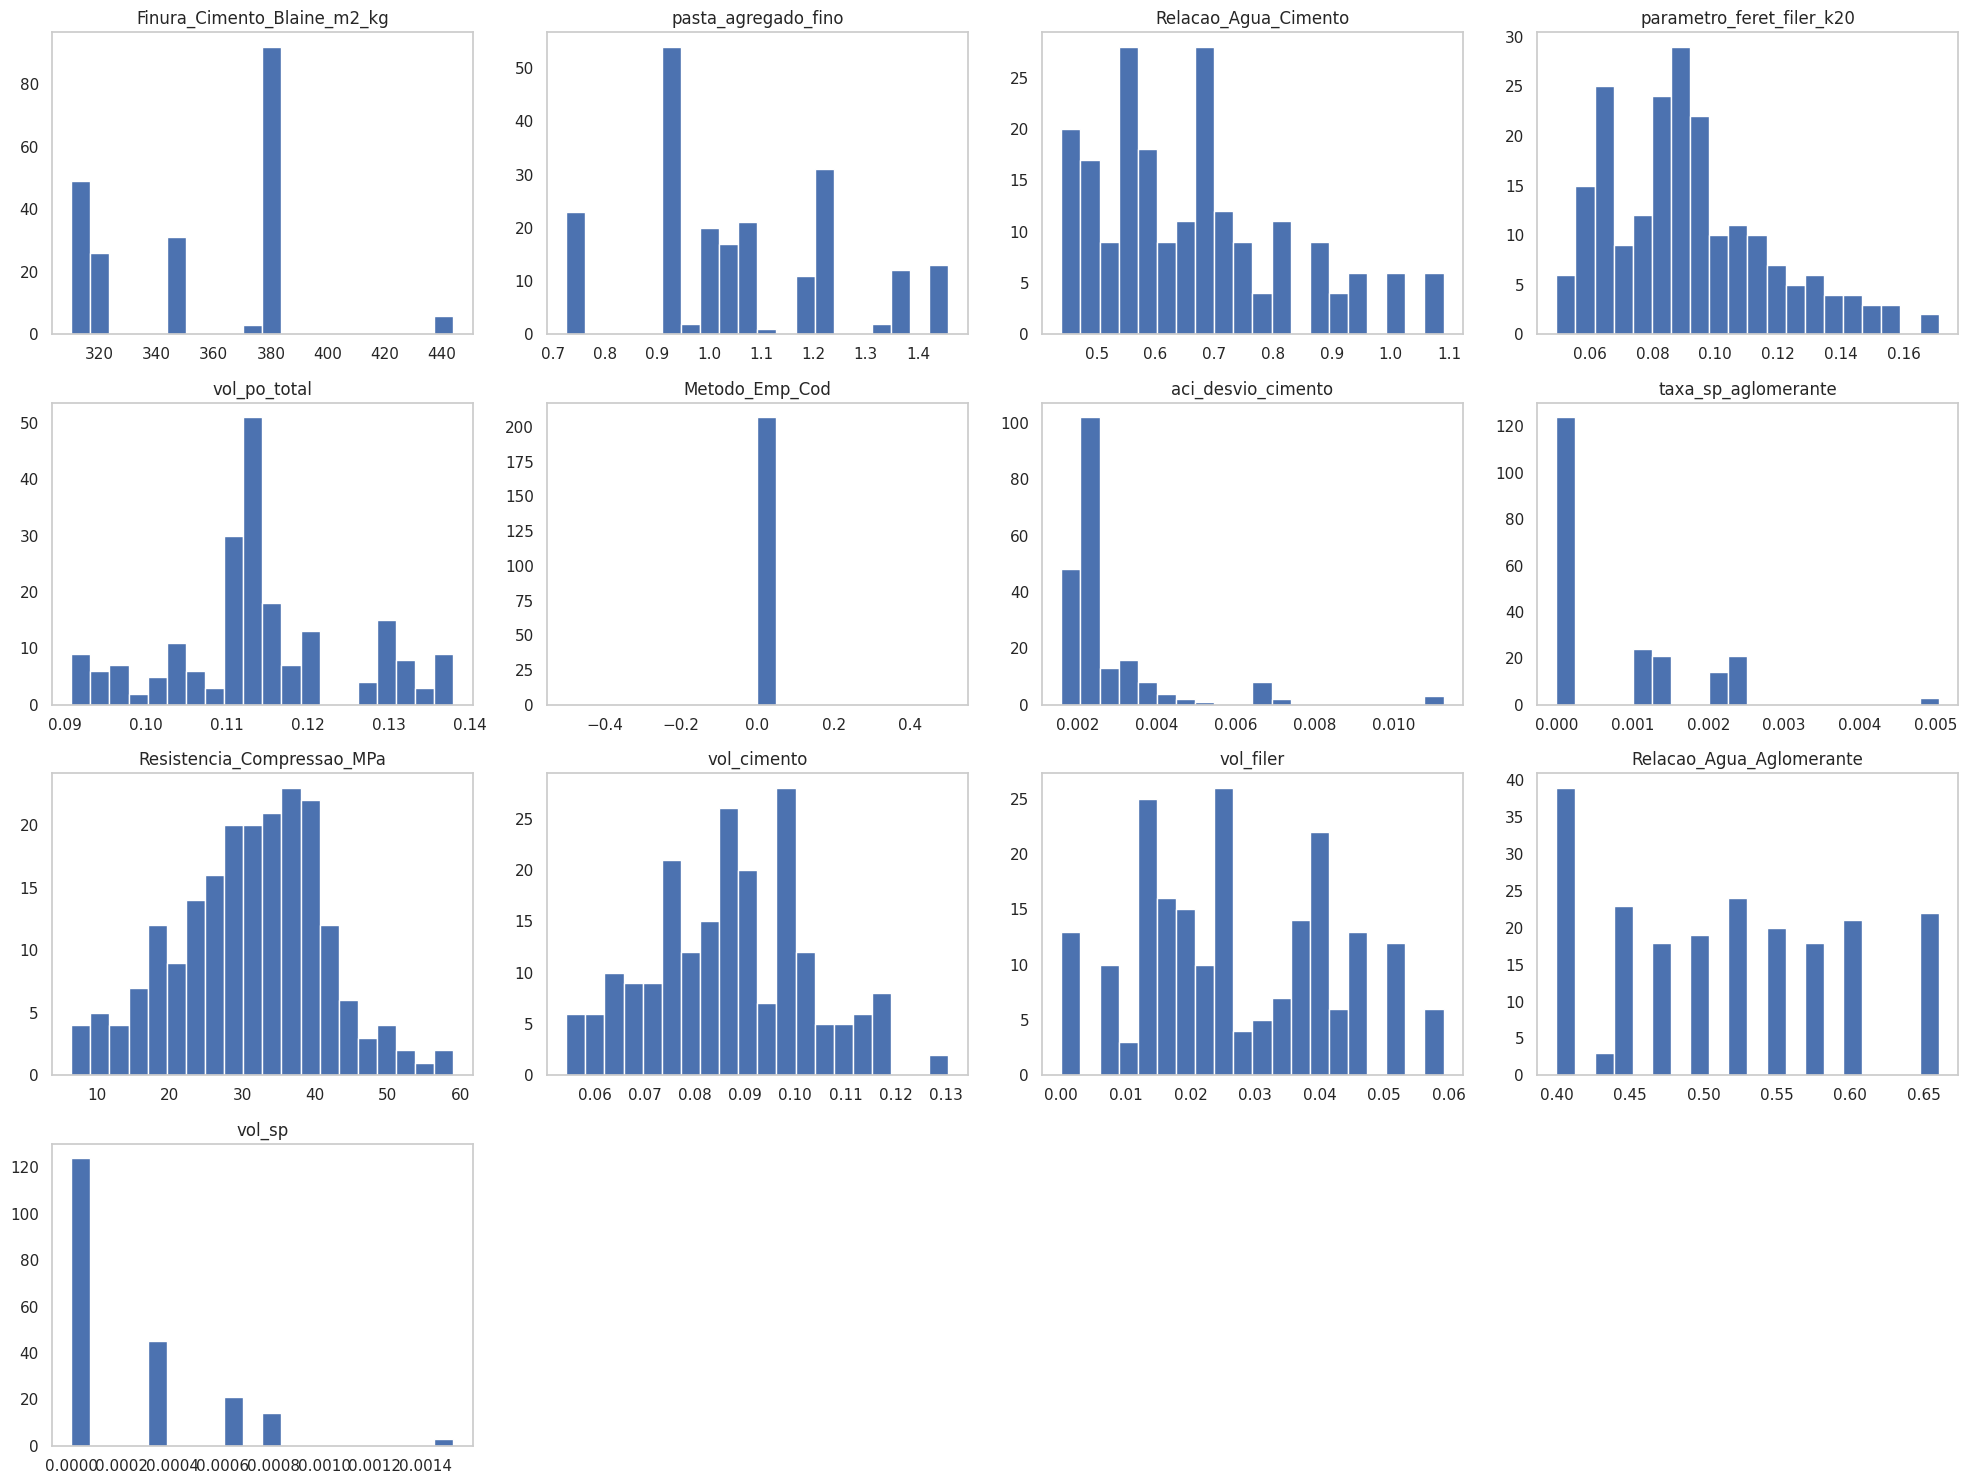

In [484]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [485]:
df_final.to_pickle(os.path.join(base_dir, f'df_resistencia_{nome_modelo}.pkl'))

In [486]:
# Limites de range das váriaveis numéricas
limites = {}
for column in df_resistencia.select_dtypes(include=['number']).columns:
    data = df_resistencia[column]
    lower_bound = data.min()
    upper_bound = data.max()
    limites[column] = (lower_bound, upper_bound)
print("Limites de range das variáveis numéricas:")
for column, (lower, upper) in limites.items():
    print(f"{column}: [{lower:.4f}, {upper:.4f}]")

Limites de range das variáveis numéricas:
Massa_Esp_Cimento_g_cm3: [3.0400, 3.2700]
Finura_Cimento_Blaine_m2_kg: [260.0000, 530.0000]
Massa_Esp_Filer_g_cm3: [2.5500, 2.9200]
Massa_Esp_Areia_g_cm3: [2.5700, 2.7000]
Massa_Esp_Brita_g_cm3: [2.5100, 2.6500]
Cimento_kg_m3: [129.3000, 487.0000]
Filer_Calcario_kg_m3: [0.0000, 184.5000]
Agua_kg_m3: [129.5000, 205.0000]
Agregado_Miudo_Total_kg_m3: [595.0000, 1074.0000]
Agregado_Graudo_Total_kg_m3: [732.4000, 1249.0000]
Superplastificante_kg_m3: [0.0000, 4.0000]
Relacao_Agua_Cimento: [0.3600, 1.4300]
ln_Idade: [0.0000, 5.8999]
Tipo_Molde_Cod: [1.0000, 5.0000]
Metodo_Emp_Cod: [0.0000, 1.0000]
Usa_SP: [0.0000, 1.0000]
Classe_Cim_OpA: [32.0000, 63.0000]
Relacao_Agua_Aglomerante: [0.3400, 0.7900]
Filer_D50_um: [1.5800, 72.0000]
D_Max: [12.5000, 30.0000]
Resistencia_Compressao_MPa: [1.0000, 71.0000]
cod_classe: [0.0000, 18.0000]
Cluster_ID: [-1.0000, 18.0000]
